In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

plt.style.use('ggplot')

%matplotlib inline

In [4]:
sales = pd.read_csv("train.csv")
vgsales = pd.read_csv("vgsales.csv")

In [5]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
sales.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [7]:
sales.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
8100,8101,CA-2017-169663,10/03/2017,13/03/2017,First Class,RH-19510,Rick Huthwaite,Home Office,United States,Los Angeles,California,90045.0,West,TEC-MA-10000984,Technology,Machines,Okidata MB760 Printer,3357.600
1300,1301,CA-2017-137043,23/12/2017,25/12/2017,Second Class,LC-17140,Logan Currie,Consumer,United States,Springfield,Virginia,22153.0,South,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",572.760
9352,9353,CA-2018-148411,24/09/2018,26/09/2018,First Class,RO-19780,Rose O'Brian,Consumer,United States,Chicago,Illinois,60623.0,Central,FUR-CH-10003973,Furniture,Chairs,GuestStacker Chair with Chrome Finish Legs,520.464
3622,3623,CA-2015-159184,14/09/2015,19/09/2015,Standard Class,JC-15775,John Castell,Consumer,United States,Macon,Georgia,31204.0,South,FUR-FU-10002878,Furniture,Furnishings,"Seth Thomas 14"" Day/Date Wall Clock",142.400
1800,1801,CA-2017-121034,08/08/2017,10/08/2017,Second Class,JF-15565,Jill Fjeld,Consumer,United States,Dallas,Texas,75081.0,Central,OFF-PA-10001994,Office Supplies,Paper,"Ink Jet Note and Greeting Cards, 8-1/2"" x 5-1/...",53.952


In [8]:
print("Rows :",sales.shape[0])
print("Columns :",sales.shape[1])

Rows : 9800
Columns : 18


In [9]:
sales.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [10]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [11]:
sales.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


## Observations

- The dataset contains retail sales records.
- Both numerical and categorical variables are present.
- Date columns need conversion to datetime format.

In [12]:
sales['Order Date'] = pd.to_datetime(sales['Order Date'],dayfirst=True)

sales['Ship Date'] = pd.to_datetime(sales['Ship Date'],dayfirst=True)

In [13]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

In [14]:
sales.isnull().sum()


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [15]:
(sales.isnull().sum()/len(sales))*100

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64

In [16]:
# Check missing values
missing = sales.isnull().sum()

missing_percent = (missing / len(sales)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

missing_df

,Missing Values,Percentage
Row ID,0,0.000000
Order ID,0,0.000000
Order Date,0,0.000000
Ship Date,0,0.000000
Ship Mode,0,0.000000
Customer ID,0,0.000000
Customer Name,0,0.000000
Segment,0,0.000000
Country,0,0.000000
City,0,0.000000


In [17]:
sales['Postal Code'] = sales['Postal Code'].fillna(0).astype(int)

In [18]:
sales.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

### Observation

The dataset contains a very small number of missing values (0.11%) in the **Postal Code** column. Since Postal Code is not used in forecasting or machine learning tasks, the missing values were replaced with **0** to preserve all records while maintaining data integrity. No other missing values were found in the dataset.

In [19]:
sales.duplicated().sum()

np.int64(0)

In [20]:
sales.drop_duplicates(inplace=True)

In [21]:
sales.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
dtype: object

In [22]:
sales['Year'] = sales['Order Date'].dt.year

sales['Month'] = sales['Order Date'].dt.month

sales['Month Name'] = sales['Order Date'].dt.month_name()

sales['Quarter'] = sales['Order Date'].dt.quarter

sales['Week Number'] = sales['Order Date'].dt.isocalendar().week

sales['Day of Week'] = sales['Order Date'].dt.day_name()

sales['Day'] = sales['Order Date'].dt.day

In [23]:
def season(month):

    if month in [12,1,2]:
        return 'Winter'

    elif month in [3,4,5]:
        return 'Spring'

    elif month in [6,7,8]:
        return 'Summer'

    else:
        return 'Autumn'

sales['Season']=sales['Month'].apply(season)

In [24]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month Name,Quarter,Week Number,Day of Week,Day,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday,8,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday,8,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday,12,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday,11,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday,11,Autumn


In [25]:
sales['Shipping Days']=(sales['Ship Date']-sales['Order Date']).dt.days

In [26]:
sales[['Order Date','Ship Date','Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [27]:
weekly_sales = sales.groupby(pd.Grouper(key='Order Date',freq='W'))['Sales'].sum()
weekly_sales.head()

Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

In [28]:
monthly_sales = sales.groupby(pd.Grouper(key='Order Date',freq='ME'))['Sales'].sum()
monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

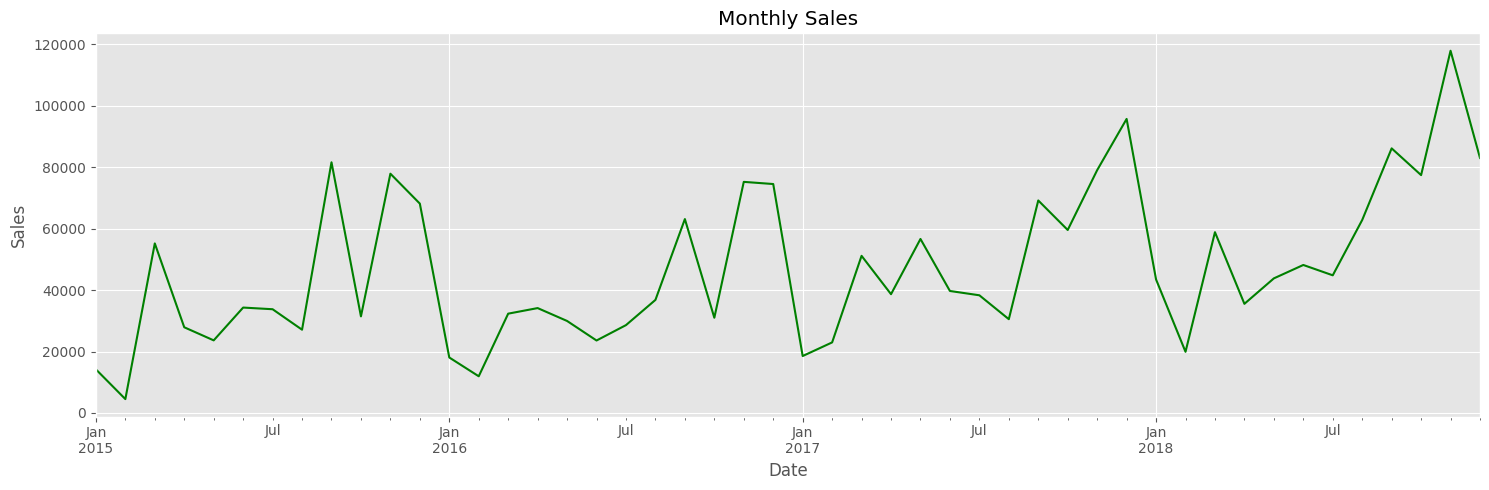

In [29]:
plt.figure(figsize=(15,5))
monthly_sales.plot(color='green')
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/monthly_sales.png", dpi=300)
plt.show()


In [30]:
category_sales = sales.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

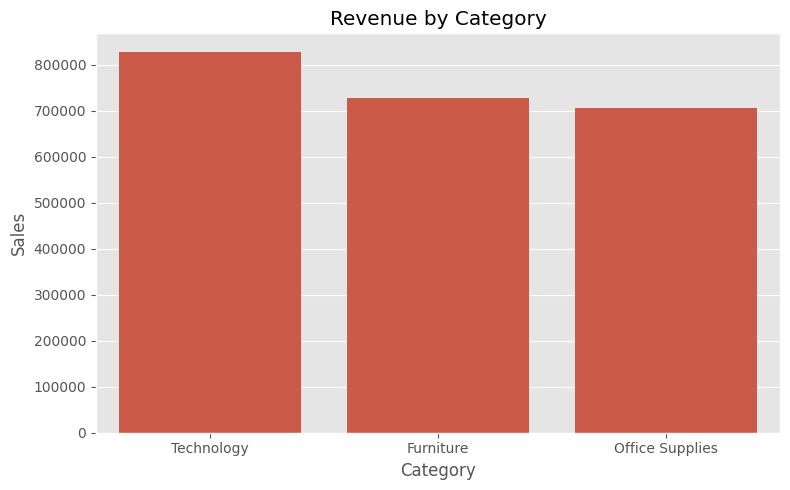

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index,y=category_sales.values)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/category_sales.png", dpi=300)
plt.show()

### Observation

Technology generates the highest revenue followed by Furniture and Office Supplies.

In [32]:
region_year=sales.groupby(['Region','Year'])['Sales'].sum().reset_index()
region_year

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


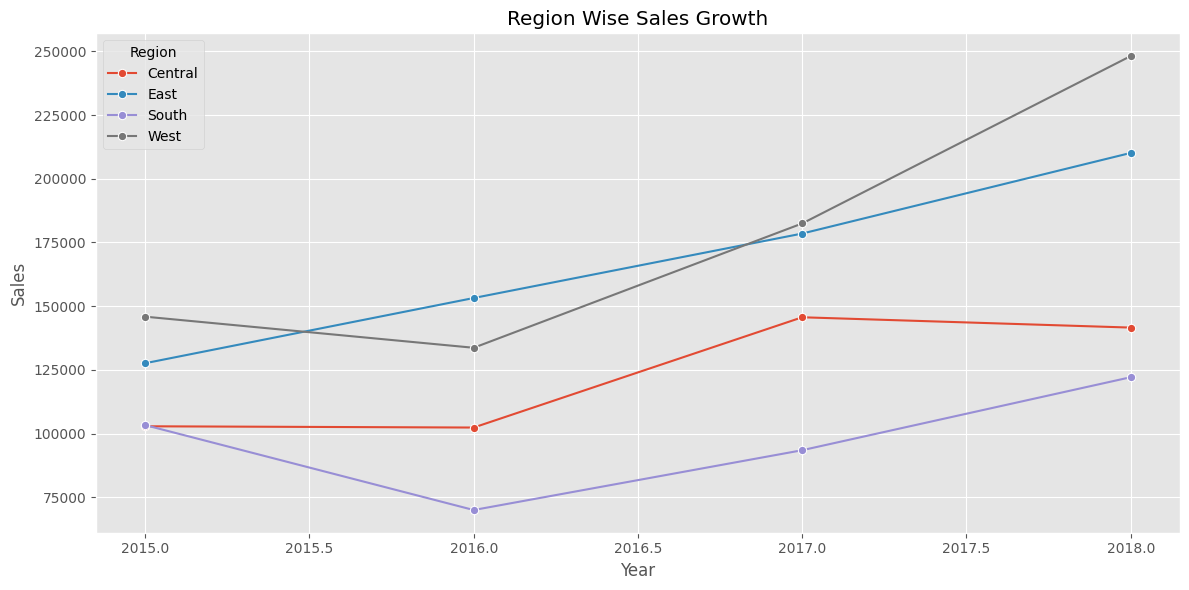

In [33]:
plt.figure(figsize=(12,6))
sns.lineplot(data=region_year,x='Year',y='Sales',hue='Region',marker='o')
plt.title("Region Wise Sales Growth")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/region_growth.png", dpi=300)
plt.show()

### Observation

The West region shows relatively steady growth across multiple years while other regions experience greater fluctuations.

In [34]:
sales['Shipping Days'].mean()

np.float64(3.9611224489795918)

In [35]:
sales.groupby('Region')['Shipping Days'].mean()

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64

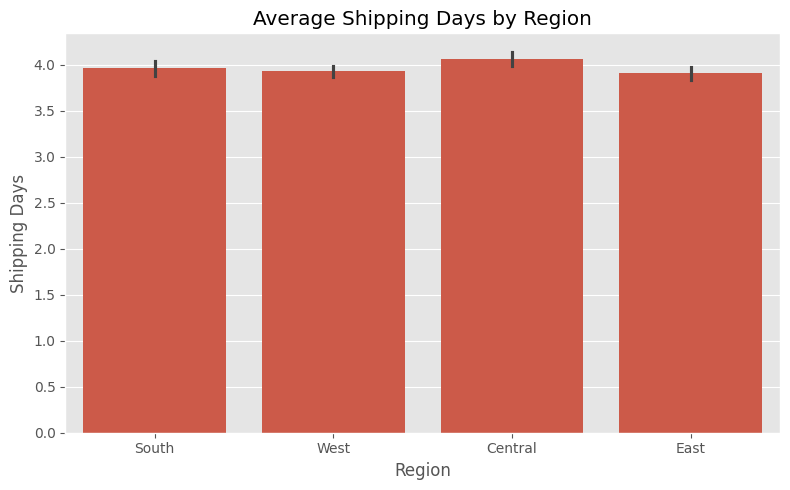

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region',y='Shipping Days',data=sales)
plt.title("Average Shipping Days by Region")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/shipping_days.png", dpi=300)
plt.show()

### Observation

Average shipping time is approximately 4 days, with only minor differences across regions.

In [37]:
seasonality=sales.groupby(['Year','Month Name'])['Sales'].sum().reset_index()
seasonality.head()

,Year,Month Name,Sales
0,2015,April,27906.8550
1,2015,August,27117.5365
2,2015,December,68167.0585
3,2015,February,4519.8920
4,2015,January,14205.7070


In [38]:
months=['January','February','March','April','May','June','July','August','September','October','November','December']
seasonality['Month Name']=pd.Categorical(seasonality['Month Name'],categories=months,ordered=True)
seasonality=seasonality.sort_values('Month Name')

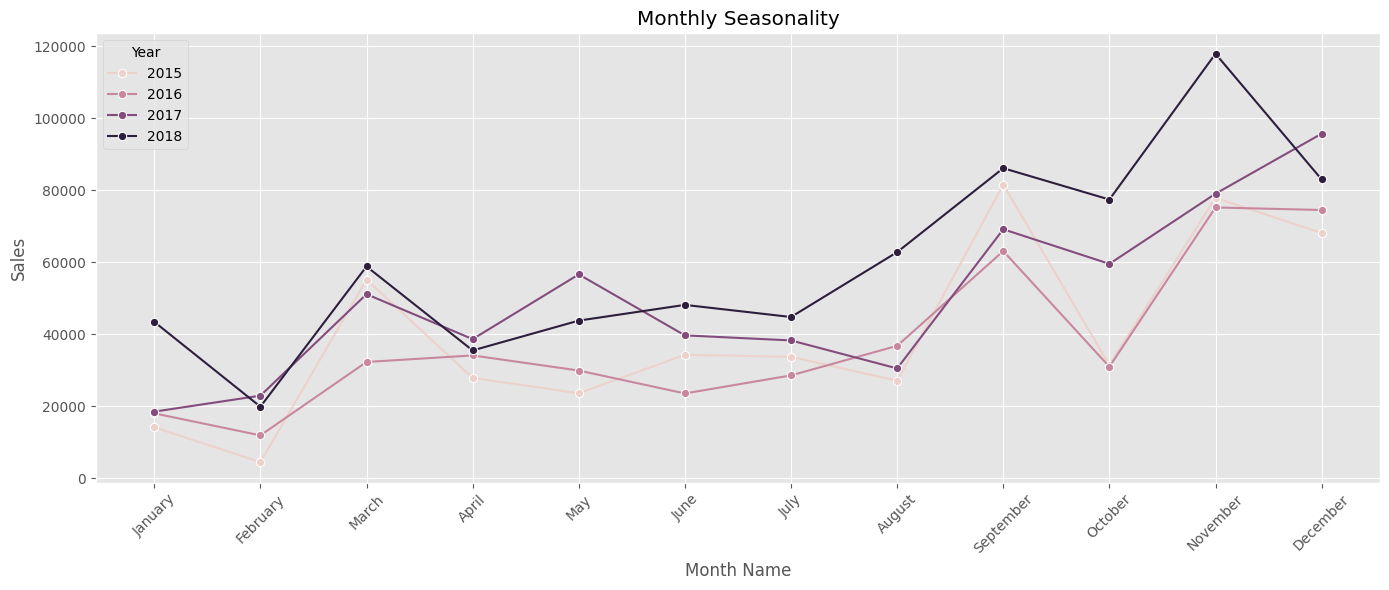

In [39]:
plt.figure(figsize=(14,6))
sns.lineplot(data=seasonality,x='Month Name',y='Sales',hue='Year',marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Seasonality")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/seasonality.png", dpi=300)
plt.show()

### Observation

Sales consistently increase during November and December, indicating strong seasonal demand driven by festive shopping and year-end purchasing.

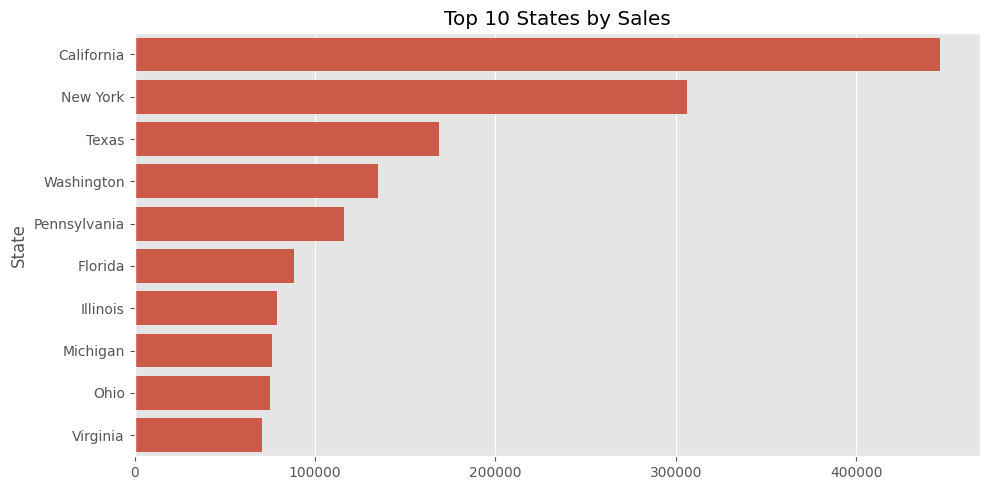

In [40]:
top_state=sales.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(y=top_state.index,x=top_state.values)
plt.title("Top 10 States by Sales")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/top_states.png", dpi=300)
plt.show()

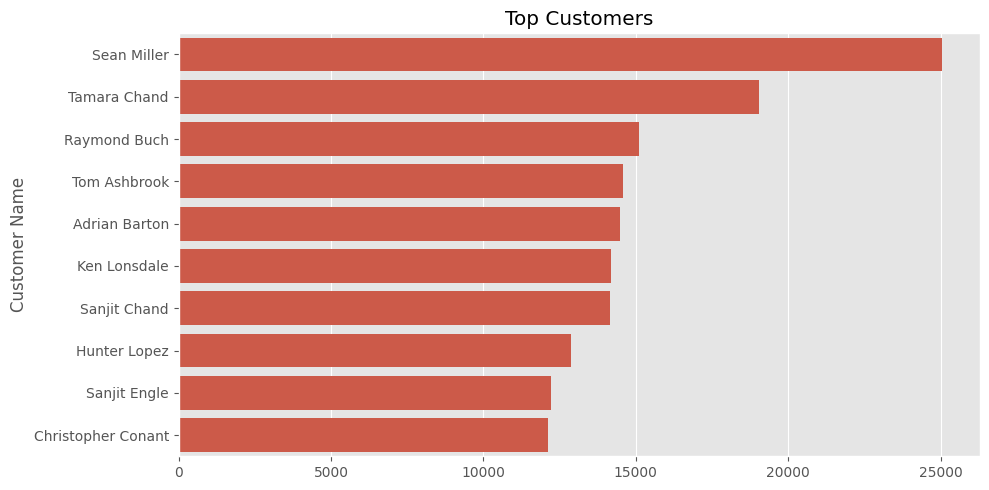

In [41]:
top_customer=sales.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(y=top_customer.index,x=top_customer.values)
plt.title("Top Customers")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/top_customers.png", dpi=300)
plt.show()

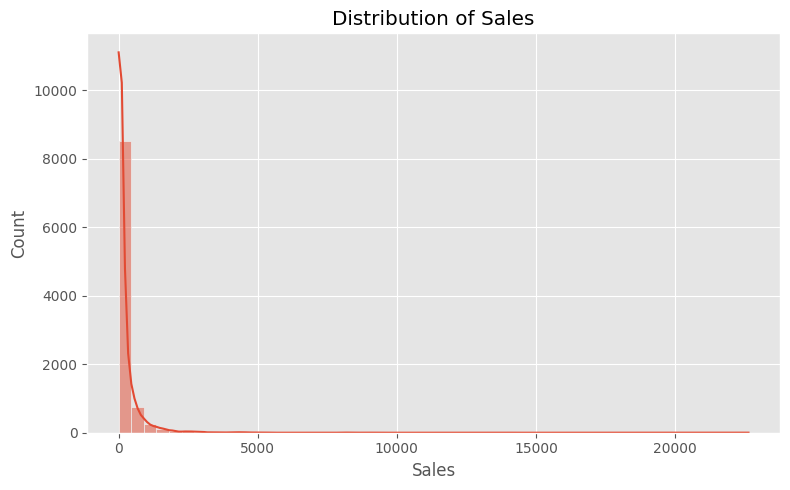

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(sales['Sales'],bins=50,kde=True)
plt.title("Distribution of Sales")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/sales_distribution.png", dpi=300)
plt.show()

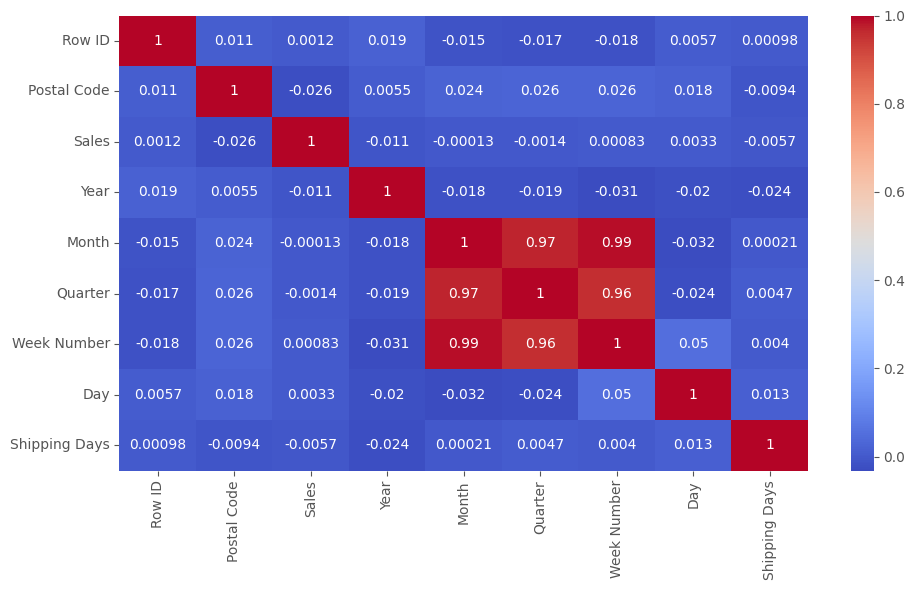

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(sales.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/correlation_heatmap.png", dpi=300)
plt.show()

In [44]:
import statsmodels
print(statsmodels.__version__)

0.14.6


In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

In [46]:
monthly_sales = sales.groupby(pd.Grouper(key='Order Date',freq='ME'))['Sales'].sum()
monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

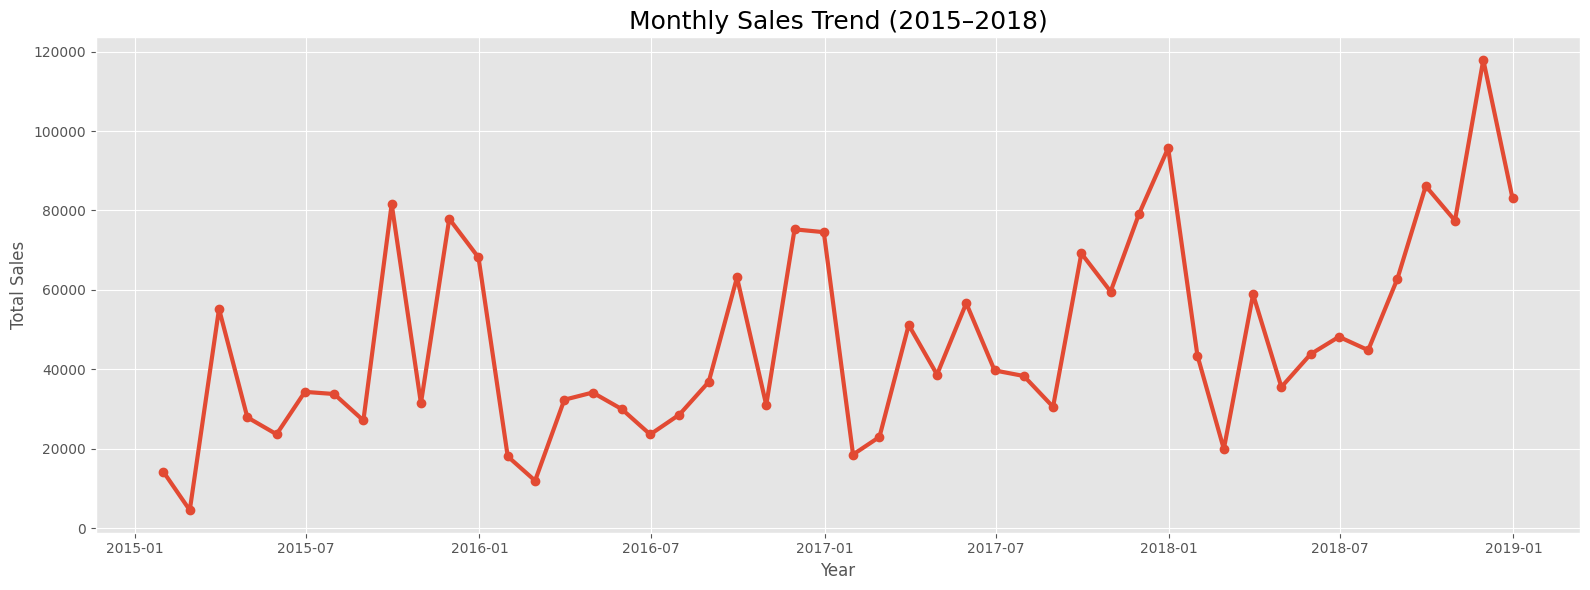

In [47]:
plt.figure(figsize=(16,6))
plt.plot(monthly_sales,linewidth=3,marker='o')
plt.title("Monthly Sales Trend (2015–2018)",fontsize=18)
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/monthly_sales_trend.png",dpi=300)
plt.show()

In [48]:
decomposition = seasonal_decompose(monthly_sales,model="additive",period=12)

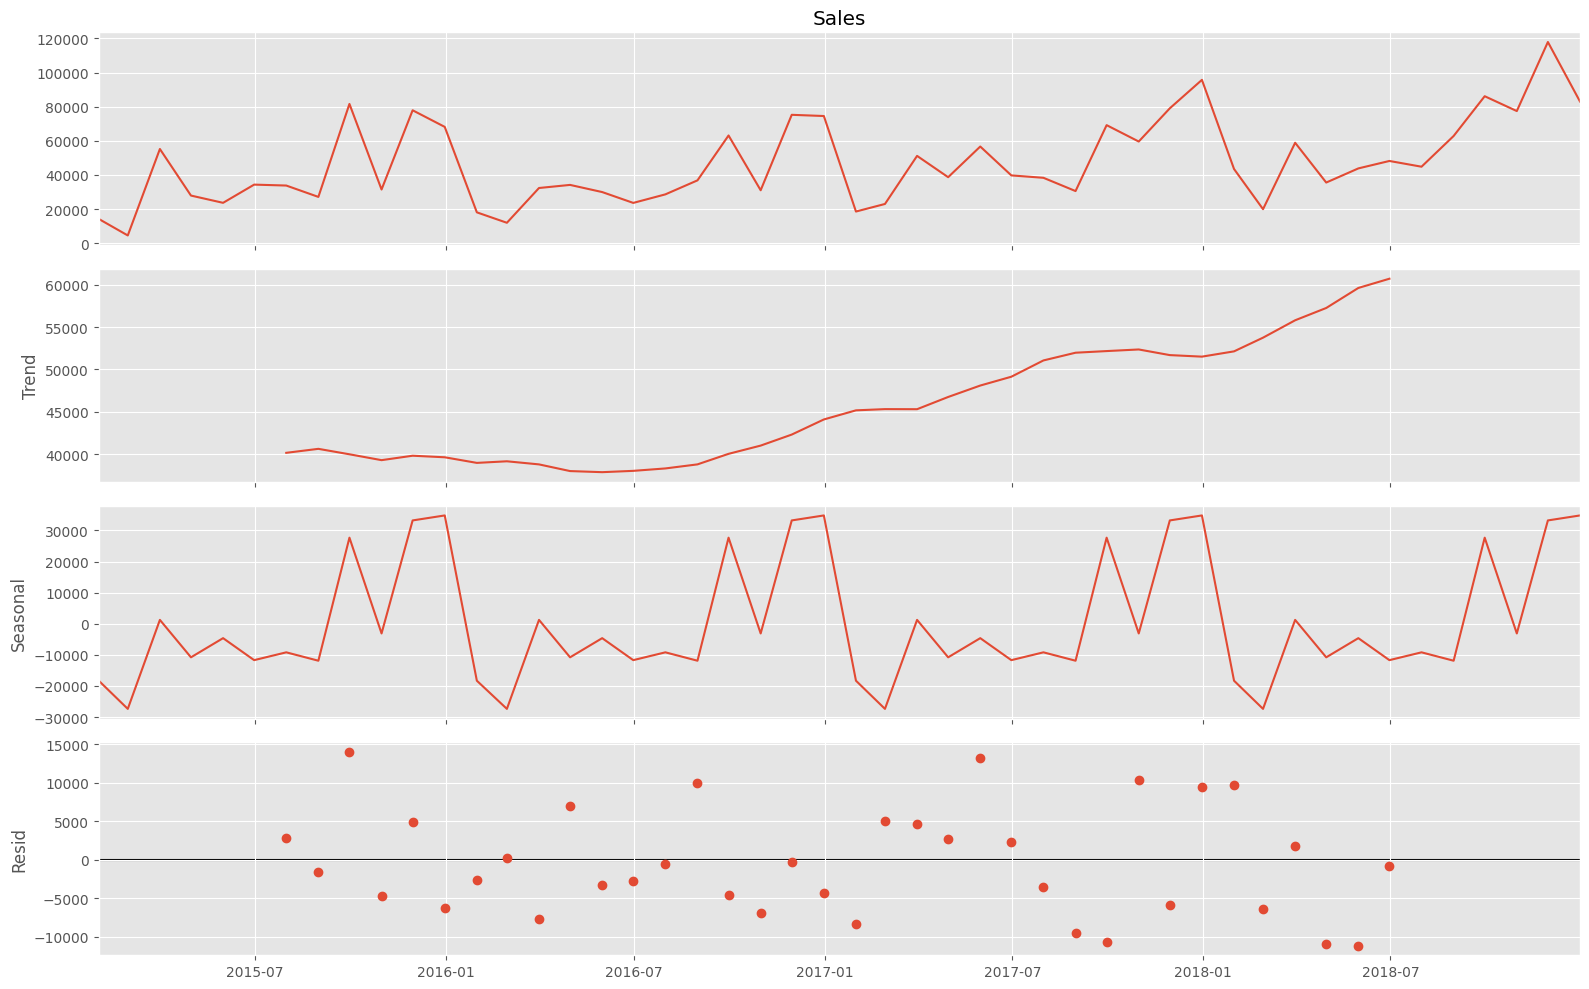

In [49]:
fig = decomposition.plot()
fig.set_size_inches(16,10)
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/time_series_decomposition.png",dpi=300)
plt.show()

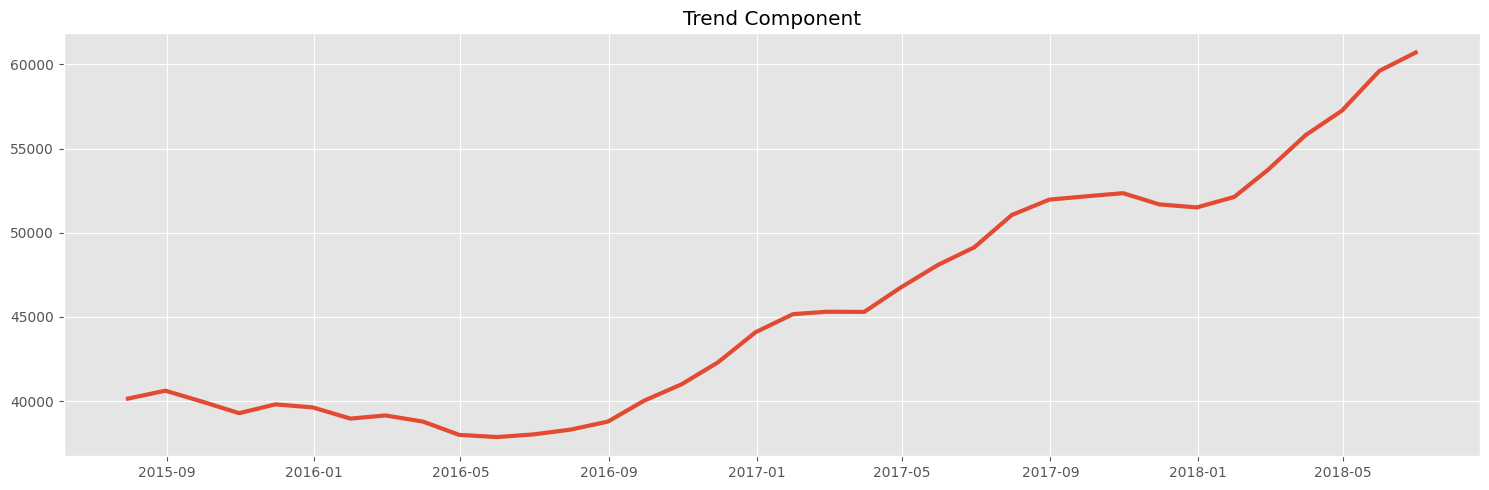

In [50]:
plt.figure(figsize=(15,5))
plt.plot(decomposition.trend,linewidth=3)
plt.title("Trend Component")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/trend_component.png",dpi=300)
plt.show()

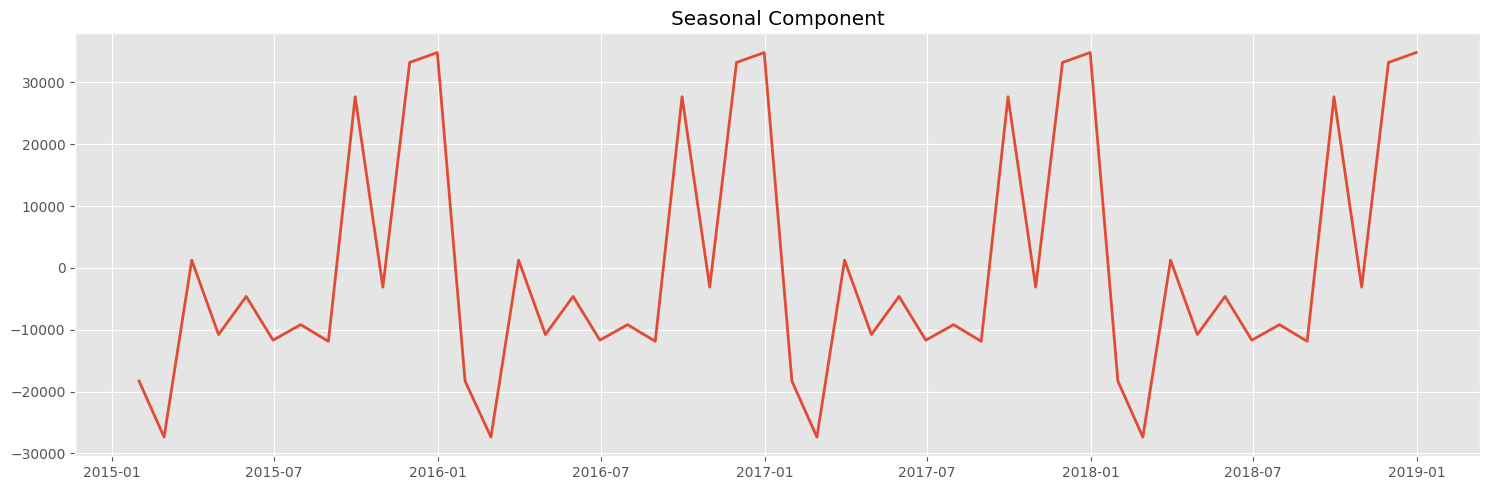

In [51]:
plt.figure(figsize=(15,5))
plt.plot(decomposition.seasonal,linewidth=2)
plt.title("Seasonal Component")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/seasonal_component.png",dpi=300)
plt.show()

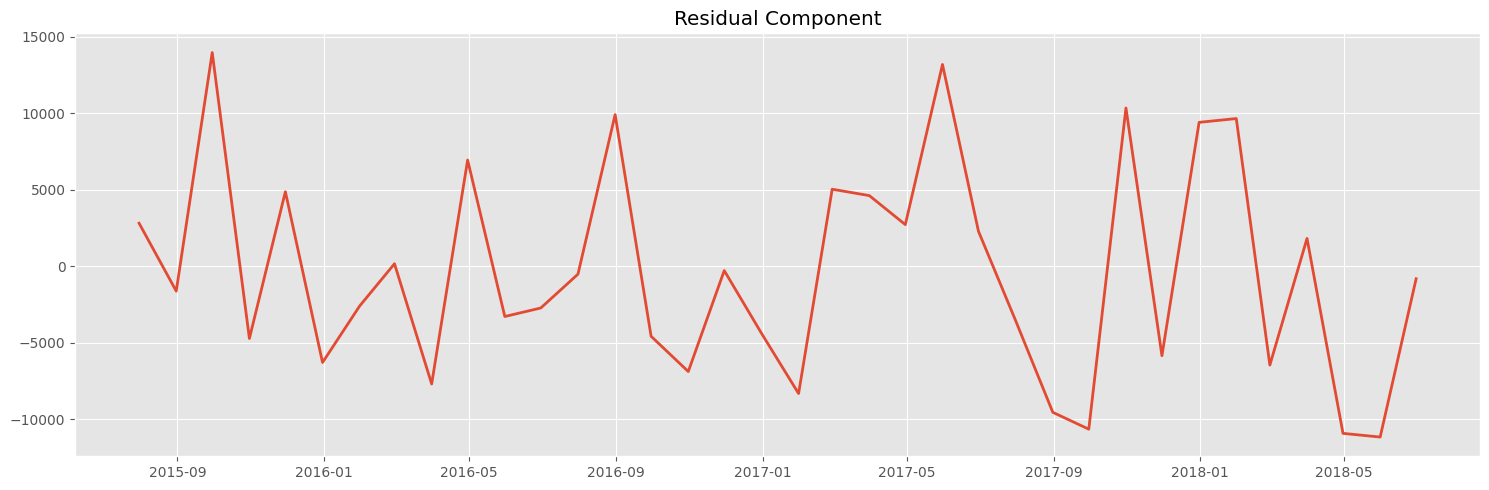

In [52]:
plt.figure(figsize=(15,5))
plt.plot(decomposition.resid,linewidth=2)
plt.title("Residual Component")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/residual_component.png",dpi=300)
plt.show()

In [53]:
residual = decomposition.resid.dropna()
highest_noise = residual.abs().sort_values(ascending=False).head(5)
print("Top 5 Months with Highest Residual Noise")
highest_noise

Top 5 Months with Highest Residual Noise


Order Date
2015-09-30    13970.933082
2017-05-31    13193.079793
2018-05-31    11157.549320
2018-04-30    10916.959724
2017-09-30    10642.715643
Name: resid, dtype: float64

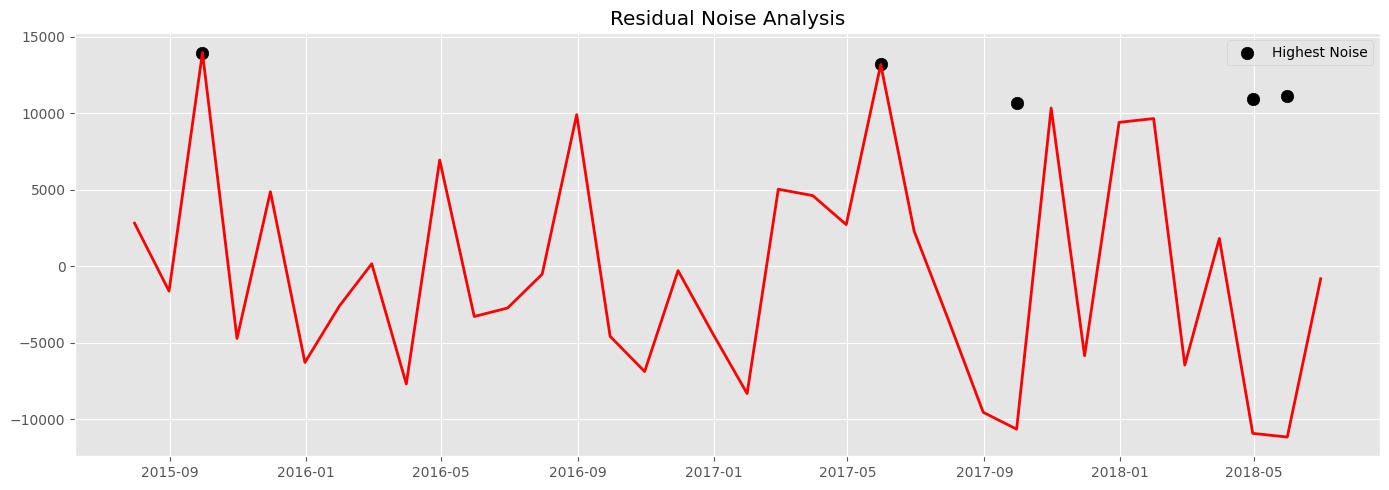

In [54]:
plt.figure(figsize=(14,5))
plt.plot(residual,color='red',linewidth=2)
plt.scatter(highest_noise.index,highest_noise.values,color='black',s=80,label='Highest Noise')
plt.legend()
plt.title("Residual Noise Analysis")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/residual_noise_analysis.png",dpi=300)
plt.show()

# Observations

### 1. Trend Analysis

The trend component shows that total sales gradually increased throughout the four-year period. This indicates continuous business growth and an expanding customer base.

### 2. Seasonal Analysis

The seasonal component displays a recurring yearly pattern. Sales consistently rise during the last quarter of the year (especially November and December), suggesting the impact of festive seasons, holiday shopping, and promotional campaigns.

### 3. Residual Analysis

The residual component represents unexpected fluctuations that cannot be explained by trend or seasonality. The months with the highest residual noise indicate unusual business events such as flash sales, bulk orders, stock shortages, or promotional discounts.

### 4. Overall Interpretation

The sales series exhibits both long-term growth and strong seasonality, making it highly suitable for forecasting using SARIMA, Prophet, and machine learning models.

In [55]:
result = adfuller(monthly_sales)
print("ADF Statistic :",result[0])
print("p-value :",result[1])
print()
for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


# What is Stationarity?

A stationary time series has constant statistical properties such as mean and variance over time.

Forecasting models such as SARIMA require stationary data because changing statistical behaviour reduces prediction accuracy.

Decision Rule:

- p-value < 0.05 → Stationary
- p-value > 0.05 → Non-Stationary

In [56]:
if result[1] < 0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is NOT Stationary")

Time Series is Stationary


In [57]:
monthly_sales_diff = monthly_sales.diff().dropna()

monthly_sales_diff.head()

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64

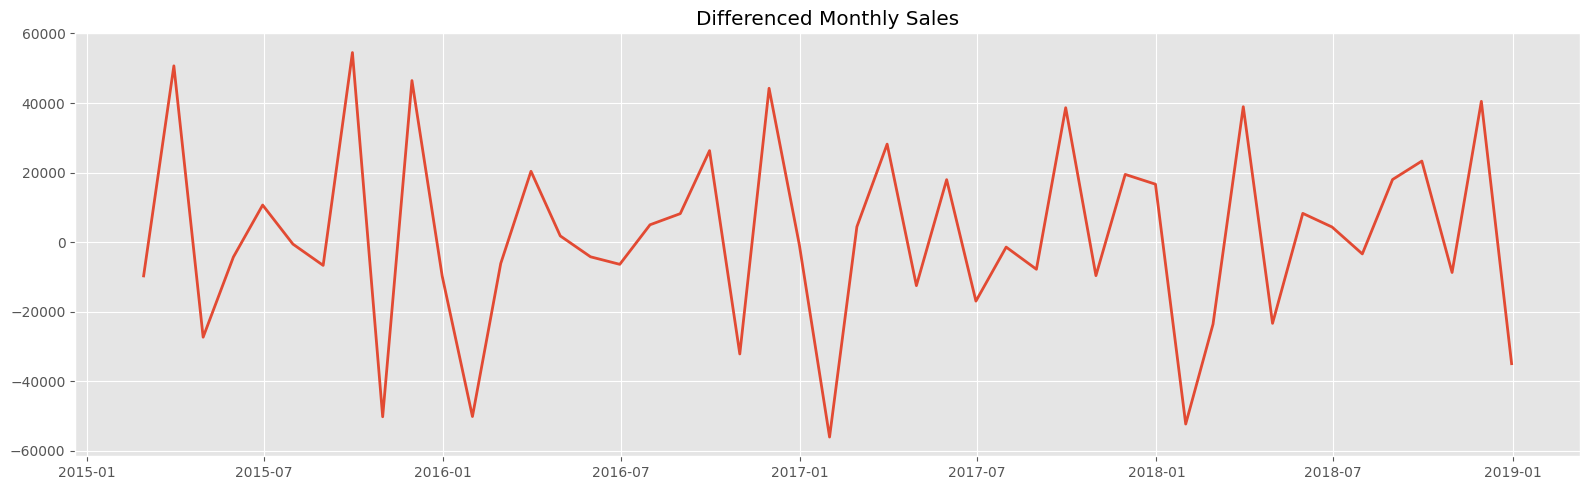

In [58]:
plt.figure(figsize=(16,5))
plt.plot(monthly_sales_diff, linewidth=2)
plt.title("Differenced Monthly Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/differenced_series.png",dpi=300)
plt.show()

In [59]:
result2 = adfuller(monthly_sales_diff)
print("ADF Statistic :",result2[0])
print("p-value :",result2[1])
print()
for key,value in result2[4].items():
    print(key,":",value)

ADF Statistic : -8.72706183035326
p-value : 3.266917547279793e-14

1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [60]:
if result2[1] < 0.05:
    print("Differenced Series is Stationary")
else:
    print("Still Non-Stationary")

Differenced Series is Stationary


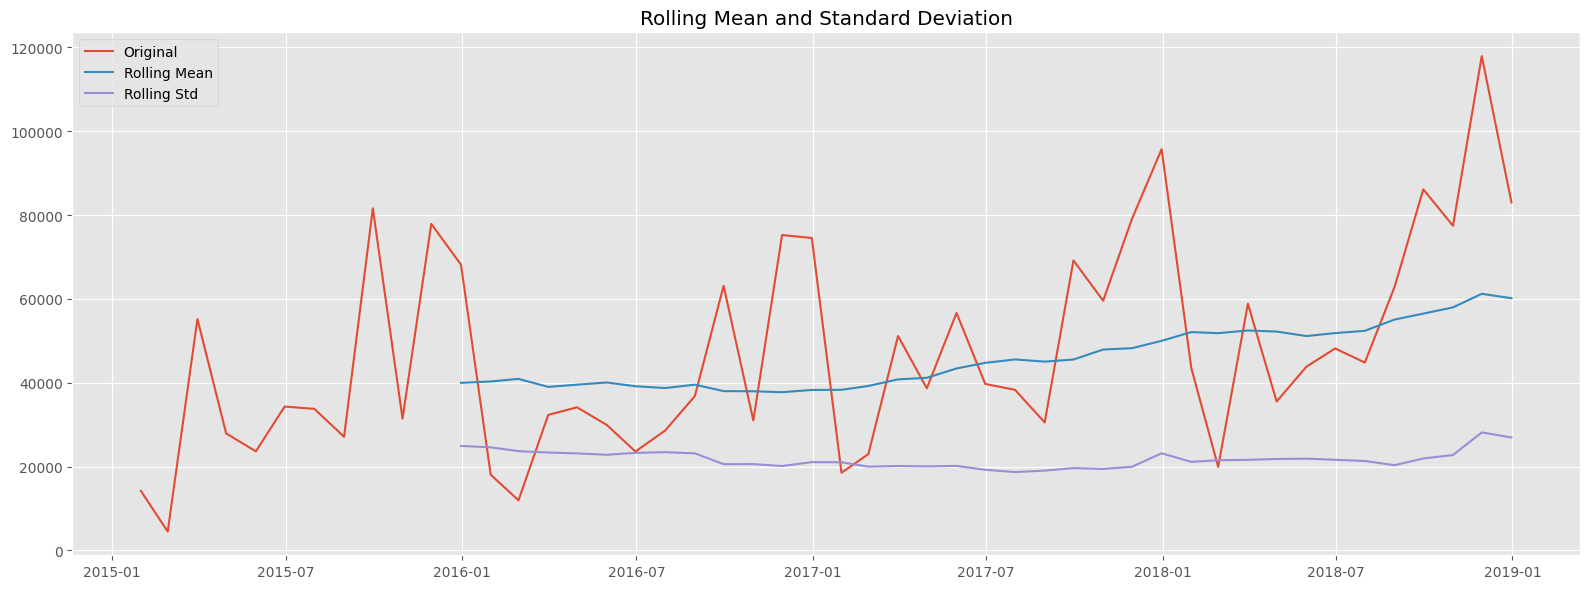

In [61]:
rolling_mean = monthly_sales.rolling(window=12).mean()
rolling_std = monthly_sales.rolling(window=12).std()
plt.figure(figsize=(16,6))
plt.plot(monthly_sales,label="Original")
plt.plot(rolling_mean,label="Rolling Mean")
plt.plot(rolling_std,label="Rolling Std")
plt.legend()
plt.grid(True)
plt.title("Rolling Mean and Standard Deviation")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/rolling_statistics.png",dpi=300)
plt.show()

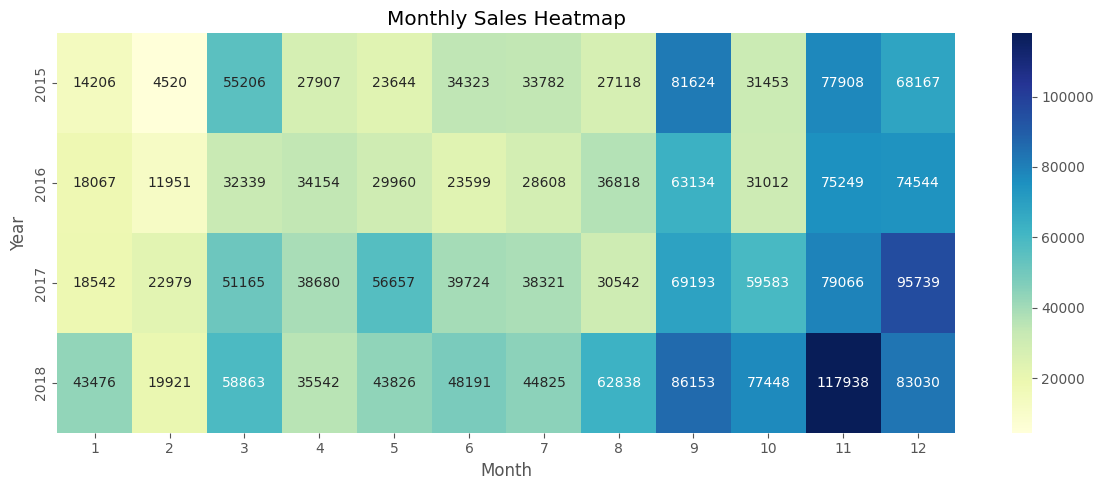

In [62]:
heatmap_data = sales.pivot_table(values="Sales",index="Year",columns="Month",aggfunc="sum")
plt.figure(figsize=(12,5))
sns.heatmap( heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Monthly Sales Heatmap")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/monthly_heatmap.png",dpi=300)
plt.show()

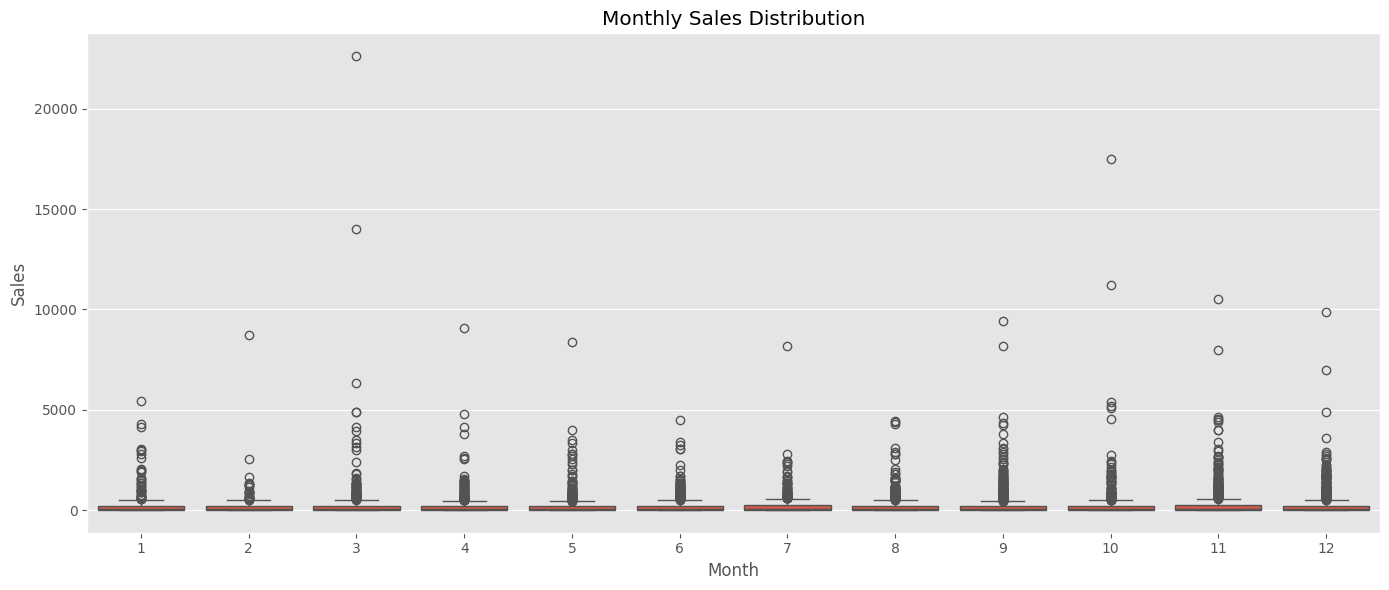

In [63]:
plt.figure(figsize=(14,6))
sns.boxplot(x='Month',y='Sales',data=sales)
plt.title("Monthly Sales Distribution")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/monthly_boxplot.png",dpi=300)
plt.show()


## Key Findings

- Monthly sales exhibit an overall increasing trend over the four-year period.
- Strong seasonality is observed, particularly during the end of each year, indicating the influence of festive and holiday shopping.
- Time series decomposition successfully separates the sales data into trend, seasonal, and residual components.
- The Augmented Dickey-Fuller (ADF) test was used to evaluate stationarity.
- Since the original series was non-stationary, first-order differencing was applied.
- After differencing, the time series became suitable for forecasting models such as SARIMA and Prophet.

In [64]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [65]:
monthly_sales = sales.groupby(pd.Grouper(key='Order Date',freq='ME'))['Sales'].sum()
monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [66]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]
print("Training Months :",len(train))
print("Testing Months :",len(test))

Training Months : 45
Testing Months : 3


In [67]:
(p,d,q)=(1,1,1)
(P,D,Q,m)=(1,1,1,12)

In [68]:
sarima_model = SARIMAX(train,order=(1,1,1),seasonal_order=(1,1,1,12),enforce_stationarity=False,enforce_invertibility=False)
sarima_fit = sarima_model.fit()

### Why these parameters?

- p=1 → Uses one previous observation.
- d=1 → First-order differencing removes trend.
- q=1 → Uses one lagged forecast error.

Seasonal parameters (1,1,1,12) capture yearly seasonality in monthly sales.

In [69]:
forecast = sarima_fit.get_forecast(steps=3)
forecast_mean = forecast.predicted_mean
confidence = forecast.conf_int()
forecast_mean

2018-10-31    60331.792100
2018-11-30    91458.220224
2018-12-31    97167.570952
Freq: ME, Name: predicted_mean, dtype: float64

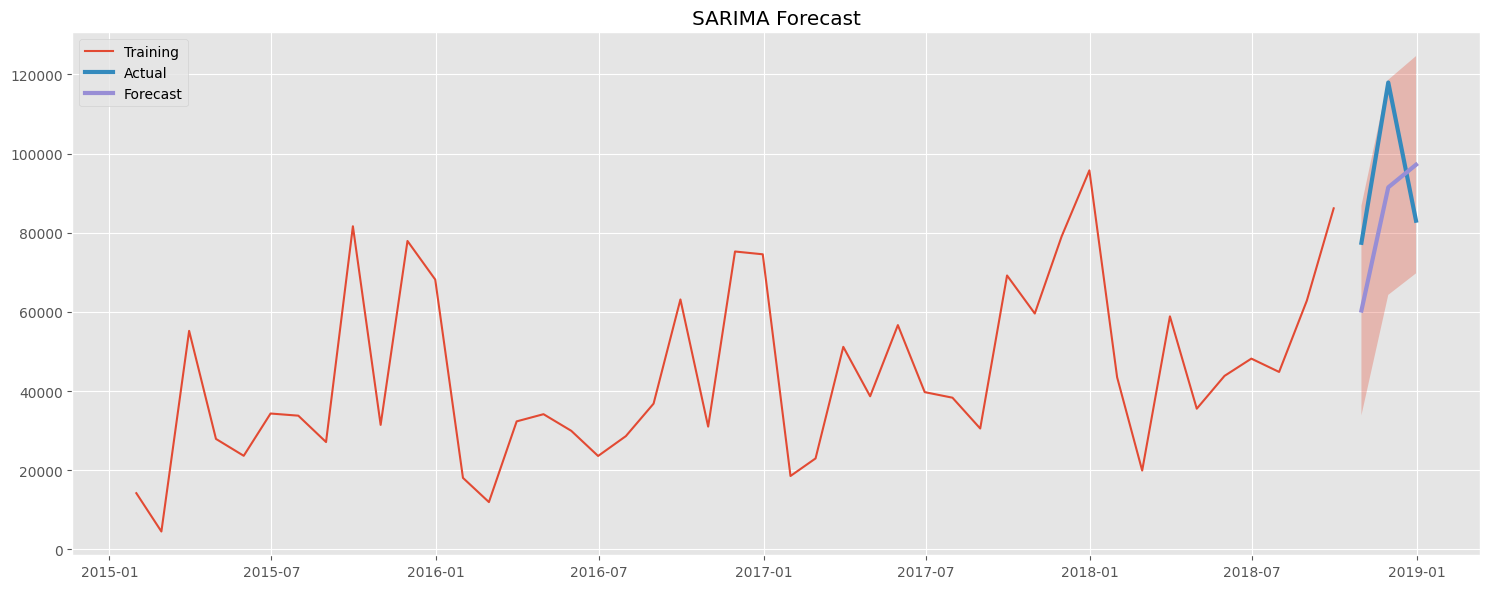

In [70]:
plt.figure(figsize=(15,6))
plt.plot(train,label="Training")
plt.plot(test,label="Actual",linewidth=3)
plt.plot(forecast_mean,label="Forecast",linewidth=3)
plt.fill_between(confidence.index,confidence.iloc[:,0],confidence.iloc[:,1],alpha=0.3)
plt.legend()
plt.title("SARIMA Forecast")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/sarima_forecast.png",dpi=300)
plt.show()

In [71]:
mae = mean_absolute_error(test,forecast_mean)
rmse = np.sqrt(mean_squared_error(test,forecast_mean))
mape = np.mean(np.abs( (test-forecast_mean)/test))*100
print("MAE :",mae)
print("RMSE :",rmse)
print("MAPE :",mape)

MAE : 19244.485342553828
RMSE : 19950.070418556625
MAPE : 20.5264319837883


In [72]:
forecast_table = pd.DataFrame({"Actual":test,
"Forecast":forecast_mean})
forecast_table

,Actual,Forecast
2018-10-31,77448.1312,60331.792100
2018-11-30,117938.1550,91458.220224
2018-12-31,83030.3888,97167.570952


In [73]:
future_forecast = sarima_fit.get_forecast(steps=3)
future_forecast.predicted_mean

2018-10-31    60331.792100
2018-11-30    91458.220224
2018-12-31    97167.570952
Freq: ME, Name: predicted_mean, dtype: float64

In [74]:
future_forecast.conf_int()

,lower Sales,upper Sales
2018-10-31,33867.663909,86795.920291
2018-11-30,64294.739753,118621.700695
2018-12-31,69727.828594,124607.313310


## Interpretation

The SARIMA model successfully captures the long-term trend and yearly seasonality in the sales data.

The forecast indicates expected sales for the next three months together with confidence intervals, allowing business managers to understand both expected demand and uncertainty.

The confidence interval widens further into the future, reflecting increasing forecasting uncertainty over longer horizons.

In [75]:
forecast_table.to_csv("sarima_forecast.csv",index=True)

In [76]:
from prophet import Prophet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [77]:
monthly_sales = sales.groupby(pd.Grouper(key='Order Date',freq='ME'))['Sales'].sum().reset_index()
monthly_sales.columns=['ds','y']
monthly_sales.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Data Preparation

Prophet requires the input dataset to contain:

- **ds** : Date column
- **y** : Target variable

The monthly sales data is therefore renamed accordingly.

In [78]:
train = monthly_sales.iloc[:-3]

test = monthly_sales.iloc[-3:]

print(train.shape)

print(test.shape)

(45, 2)
(3, 2)


In [79]:
prophet_model = Prophet(yearly_seasonality=True,weekly_seasonality=False,daily_seasonality=False)
prophet_model.fit(train)

16:18:10 - cmdstanpy - INFO - Chain [1] start processing
16:18:10 - cmdstanpy - INFO - Chain [1] done processing


In [80]:
future = prophet_model.make_future_dataframe(periods=3,freq='ME')
future.tail()

,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [81]:
forecast = prophet_model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33308.214631,6564.021513,23232.874417,33308.214631,33308.214631,-18874.429670,-18874.429670,-18874.429670,-18874.429670,-18874.429670,-18874.429670,0.0,0.0,0.0,14433.784960
1,2015-02-28,33767.643626,-5032.386376,10738.723525,33767.643626,33767.643626,-30869.543104,-30869.543104,-30869.543104,-30869.543104,-30869.543104,-30869.543104,0.0,0.0,0.0,2898.100522
2,2015-03-31,34276.297157,44440.489687,59861.627553,34276.297157,34276.297157,17890.437293,17890.437293,17890.437293,17890.437293,17890.437293,17890.437293,0.0,0.0,0.0,52166.734451
3,2015-04-30,34768.542510,12725.205256,28894.523467,34768.542510,34768.542510,-13661.251247,-13661.251247,-13661.251247,-13661.251247,-13661.251247,-13661.251247,0.0,0.0,0.0,21107.291263
4,2015-05-31,35277.196041,14658.408210,30490.455416,35277.196041,35277.196041,-12398.630441,-12398.630441,-12398.630441,-12398.630441,-12398.630441,-12398.630441,0.0,0.0,0.0,22878.565600


In [82]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558236,39140.864074,55516.638556
44,2018-09-30,86613.953316,78174.655683,93934.684287
45,2018-10-31,51318.943858,43916.382434,59319.473703
46,2018-11-30,90325.654784,82472.352017,98549.828583
47,2018-12-31,90041.084479,81948.345193,98406.722108


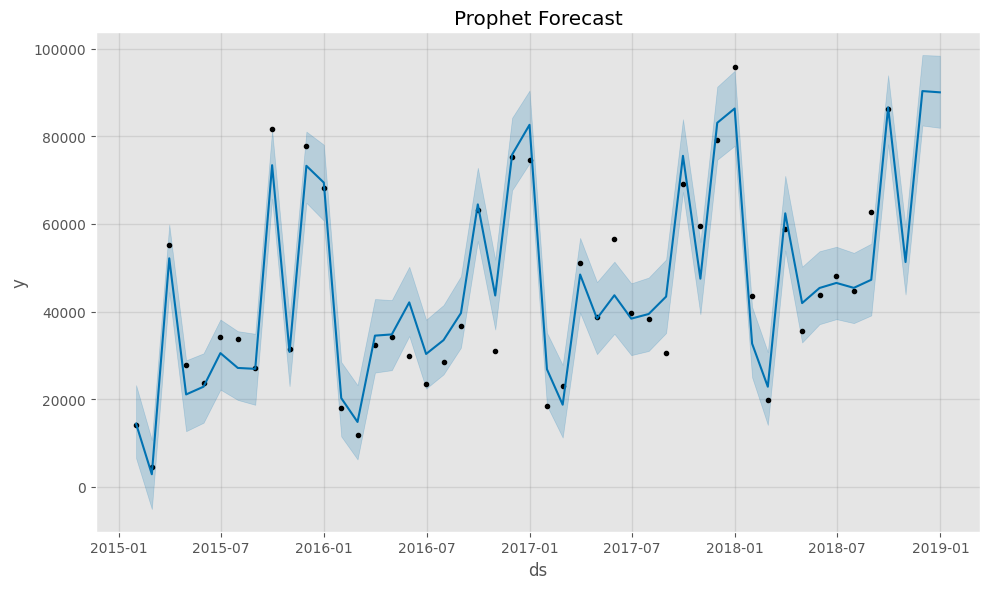

In [83]:
fig = prophet_model.plot(forecast)
plt.title("Prophet Forecast")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/prophet_forecast.png",dpi=300)
plt.show()

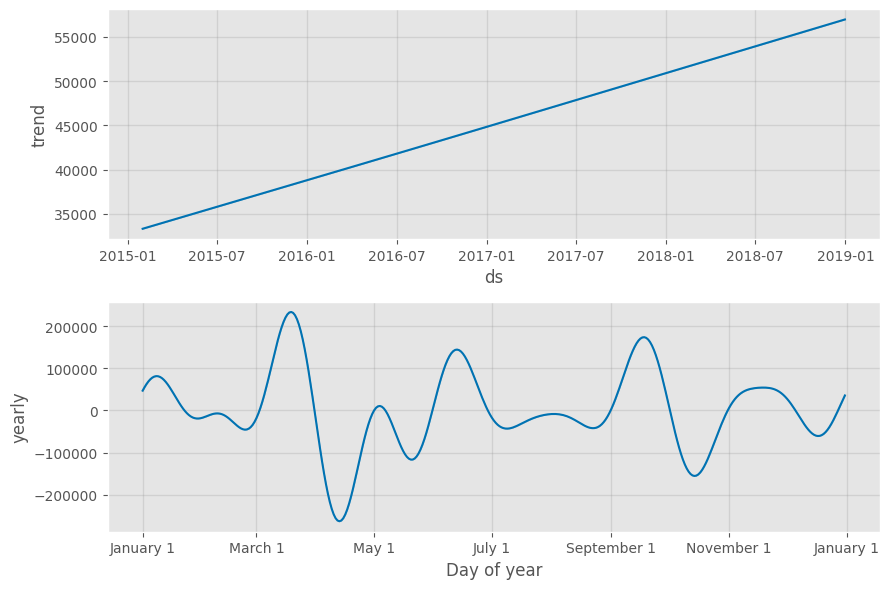

In [84]:
fig2 = prophet_model.plot_components(forecast)
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/prophet_components.png",dpi=300)
plt.show()

# Interpretation of Prophet Components

## Trend Component

The trend component shows the long-term movement in monthly sales. It indicates a gradual increase in sales over the four-year period, reflecting overall business growth.

## Yearly Seasonality

The yearly seasonality plot reveals recurring annual sales patterns. Sales increase during the last quarter of the year, particularly around November and December, likely due to festive seasons, holiday shopping, and promotional campaigns.

## Weekly Seasonality

Weekly seasonality was **disabled** in the Prophet model because the dataset was aggregated to **monthly sales**. Since each observation represents an entire month, weekly patterns cannot be identified reliably and are therefore not meaningful for this analysis.

In [85]:
forecast[['ds','trend','yhat','yhat_lower','yhat_upper']].tail(3)

,ds,trend,yhat,yhat_lower,yhat_upper
45,2018-10-31,55957.582932,51318.943858,43916.382434,59319.473703
46,2018-11-30,56456.913322,90325.654784,82472.352017,98549.828583
47,2018-12-31,56972.888059,90041.084479,81948.345193,98406.722108


In [86]:
prediction = forecast[['ds','yhat']].tail(3)
prediction

,ds,yhat
45,2018-10-31,51318.943858
46,2018-11-30,90325.654784
47,2018-12-31,90041.084479


In [145]:
prediction = forecast[['ds', 'yhat']].tail(3)

prophet_comparison = test.merge(
    prediction,
    on='ds'
)

In [147]:
mae_prophet = mean_absolute_error( prophet_comparison['y'], prophet_comparison['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(prophet_comparison['y'],prophet_comparison['yhat']))
mape_prophet = np.mean(np.abs((prophet_comparison['y']-prophet_comparison['yhat'])/prophet_comparison['y']))*100
print("MAE :",mae_prophet)
print("RMSE :",rmse_prophet)
print("MAPE :",mape_prophet)

MAE : 20250.794412605515
RMSE : 22318.41133286054
MAPE : 21.864628273960815


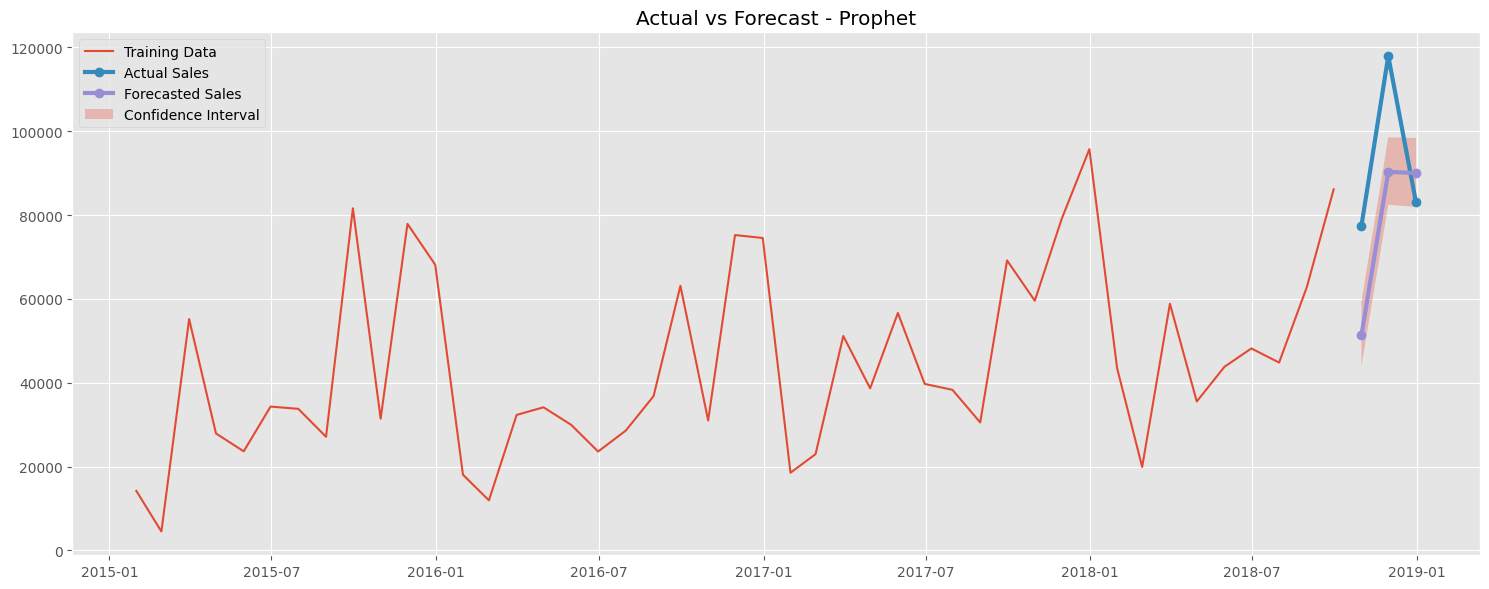

In [149]:
plt.figure(figsize=(15,6))
plt.plot(train['ds'],train['y'],label="Training Data")
plt.plot(prophet_comparison['ds'],prophet_comparison['y'],marker='o',linewidth=3,label="Actual Sales")
plt.plot(prophet_comparison['ds'],prophet_comparison['yhat'],marker='o',linewidth=3,label="Forecasted Sales")
plt.fill_between(prophet_comparison['ds'],forecast[['yhat_lower']].tail(3).values.flatten(),forecast[['yhat_upper']].tail(3).values.flatten(),alpha=0.3,label="Confidence Interval")
plt.legend()
plt.grid(True)
plt.title("Actual vs Forecast - Prophet")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/prophet_actual_vs_forecast.png",dpi=300)
plt.show()

In [150]:
prophet_comparison.to_csv("prophet_forecast.csv",index=False)

# Prophet Model Interpretation

The Prophet model successfully captures the long-term sales trend and yearly seasonality present in the Superstore sales dataset.

Compared to traditional statistical models, Prophet requires minimal parameter tuning while automatically modelling trend changes and seasonal effects.

The three-month forecast provides expected future sales along with confidence intervals, enabling business managers to estimate future demand and inventory requirements.

In [151]:
import xgboost as xgb

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [152]:
monthly = sales.groupby(pd.Grouper(key='Order Date',freq='ME'))['Sales'].sum().reset_index()
monthly.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [153]:
monthly['Lag1'] = monthly['Sales'].shift(1)
monthly['Lag2'] = monthly['Sales'].shift(2)
monthly['Lag3'] = monthly['Sales'].shift(3)

monthly['Rolling3'] = monthly['Sales'].rolling(3).mean()
monthly['Rolling6'] = monthly['Sales'].rolling(6).mean()

monthly['Year'] = monthly['Order Date'].dt.year
monthly['Month'] = monthly['Order Date'].dt.month
monthly['Quarter'] = monthly['Order Date'].dt.quarter

## Feature Engineering

The following predictive features were created:

- Year
- Month
- Quarter
- Previous Month Sales (Lag1)
- Two-Month Lag (Lag2)
- Rolling Mean (3 Months)
- Rolling Mean (6 Months)

These features help the machine learning model capture historical sales behaviour.

In [154]:
monthly['Month_sin'] = np.sin(2*np.pi*monthly['Month']/12)
monthly['Month_cos'] = np.cos(2*np.pi*monthly['Month']/12)

In [155]:
X = monthly[['Year','Month','Quarter','Lag1','Lag2','Lag3','Rolling3','Rolling6','Month_sin','Month_cos']]
y = monthly['Sales']

In [156]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]
y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

In [157]:
model = xgb.XGBRegressor(n_estimators=200,learning_rate=0.05,max_depth=4,random_state=42)
model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Parameter Selection

- n_estimators = 200 → Number of boosting trees.
- learning_rate = 0.05 → Slower learning improves generalization.
- max_depth = 4 → Prevents overfitting while capturing nonlinear relationships.

In [158]:
prediction = model.predict(X_test)
prediction

array([88090.51, 89232.29, 89075.07], dtype=float32)

In [159]:
future_forecast = pd.DataFrame({"Forecast Month":[ "Month 1","Month 2","Month 3"],"Predicted Sales":prediction})
future_forecast

,Forecast Month,Predicted Sales
0,Month 1,88090.507812
1,Month 2,89232.289062
2,Month 3,89075.070312


In [160]:
mae_xgb = mean_absolute_error(y_test,prediction)
rmse_xgb = np.sqrt( mean_squared_error(y_test, prediction))
mape_xgb = np.mean( np.abs((y_test-prediction)/y_test))*100
print("MAE :",mae_xgb)
print("RMSE :",rmse_xgb)
print("MAPE :",mape_xgb)

MAE : 15130.974687499998
RMSE : 18016.891091154517
MAPE : 15.120380219696038


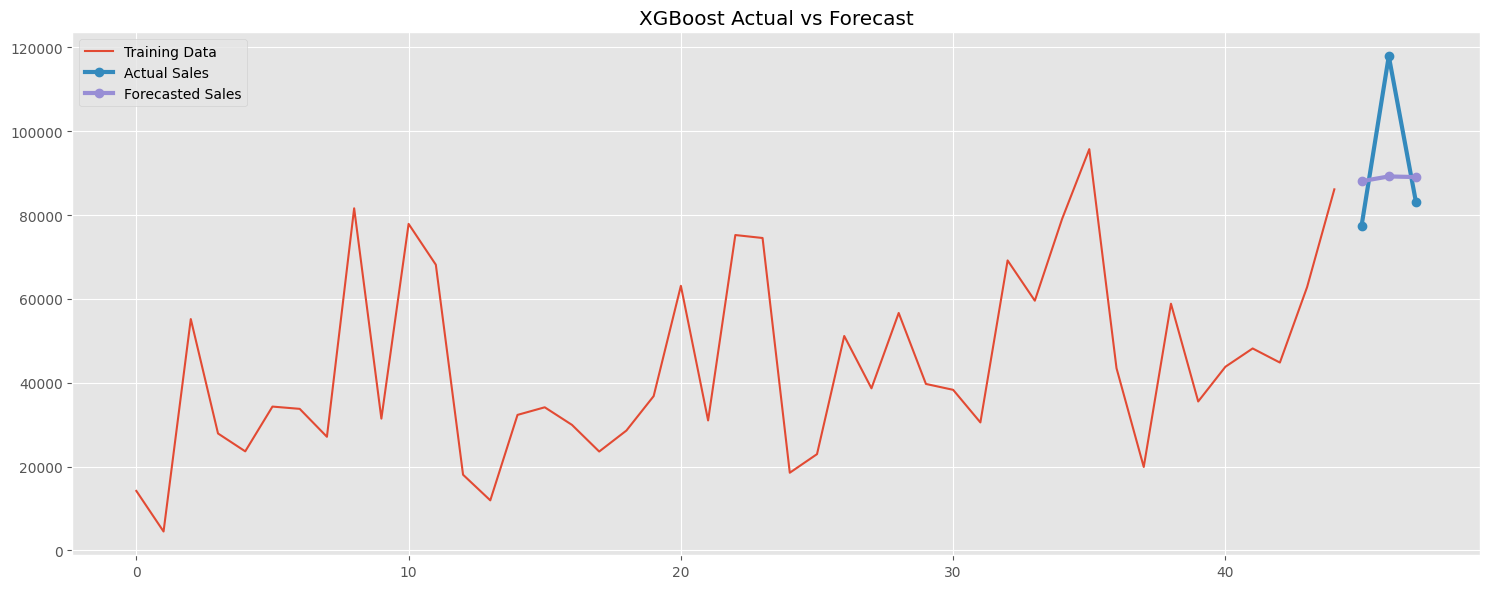

In [161]:
plt.figure(figsize=(15,6))
plt.plot(y_train.index,y_train,label="Training Data")
plt.plot(y_test.index,y_test,marker='o',linewidth=3,label="Actual Sales")
plt.plot(y_test.index,prediction,marker='o',linewidth=3,label="Forecasted Sales")
plt.legend()
plt.grid(True)
plt.title("XGBoost Actual vs Forecast")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/xgboost_forecast.png",dpi=300)
plt.show()

In [162]:
importance = pd.DataFrame({"Feature":X.columns,"Importance":model.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
importance

,Feature,Importance
1,Month,0.615375
6,Rolling3,0.116548
5,Lag3,0.056593
9,Month_cos,0.051716
4,Lag2,0.048348
7,Rolling6,0.046155
3,Lag1,0.032685
0,Year,0.022796
8,Month_sin,0.009783
2,Quarter,0.000000


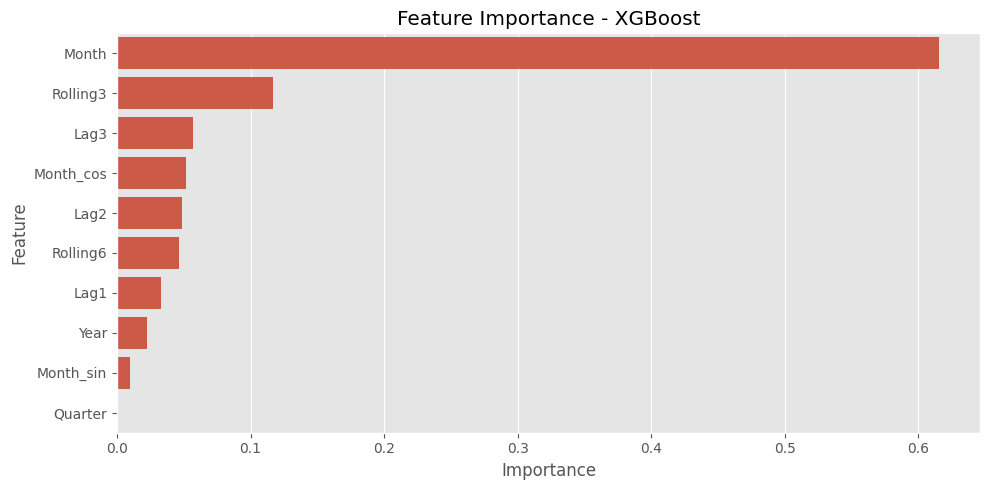

In [163]:
plt.figure(figsize=(10,5))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Feature Importance - XGBoost")
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/xgboost_feature_importance.png",dpi=300)
plt.show()

In [164]:
comparison_xgb = pd.DataFrame({"Actual":y_test.values, "Forecast":prediction})
comparison_xgb

,Actual,Forecast
0,77448.1312,88090.507812
1,117938.1550,89232.289062
2,83030.3888,89075.070312


In [165]:
comparison_xgb.to_csv("xgboost_forecast.csv",index=False)

# Business Interpretation

The XGBoost model learns complex relationships from engineered time-series features rather than relying solely on statistical assumptions.

The feature importance analysis identifies which historical variables contribute the most to forecasting future sales. This enables businesses to understand which temporal patterns have the greatest influence on sales performance.

The predicted sales closely follow the observed values, demonstrating the capability of machine learning methods for demand forecasting.

In [168]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        mae,
        mae_prophet,
        mae_xgb
    ],

    "RMSE":[
        rmse,
        rmse_prophet,
        rmse_xgb
    ],

    "MAPE":[
        mape,
        mape_prophet,
        mape_xgb
    ],

    "Forecast Month 1":[
        forecast_mean.iloc[0],
        prophet_comparison['yhat'].iloc[0],
        prediction[0]
    ],

    "Forecast Month 2":[
        forecast_mean.iloc[1],
        prophet_comparison['yhat'].iloc[1],
        prediction[1]
    ],

    "Forecast Month 3":[
        forecast_mean.iloc[2],
        prophet_comparison['yhat'].iloc[2],
        prediction[2]
    ]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.485343,19950.070419,20.526432,60331.792100,91458.220224,97167.570952
1,Prophet,20250.794413,22318.411333,21.864628,51318.943858,90325.654784,90041.084479
2,XGBoost,15130.974687,18016.891091,15.120380,88090.507812,89232.289062,89075.070312


In [169]:
best_model = comparison.loc[comparison["RMSE"].idxmin()]
print("Best Forecasting Model")
best_model

Best Forecasting Model


Model                    XGBoost
MAE                 15130.974687
RMSE                18016.891091
MAPE                    15.12038
Forecast Month 1    88090.507812
Forecast Month 2    89232.289062
Forecast Month 3    89075.070312
Name: 2, dtype: object

In [170]:
comparison.to_csv("model_comparison.csv",index=False)

# Model Comparison and Recommendation

Three forecasting approaches were evaluated:

1. SARIMA
2. Prophet
3. XGBoost

Performance was compared using Mean Absolute Error (MAE), Root Mean Square Error (RMSE), and Mean Absolute Percentage Error (MAPE).

The model with the lowest RMSE and MAPE is recommended as the final forecasting model because it provides the highest prediction accuracy on the test dataset.

Using multiple forecasting techniques improves confidence in business decision-making and enables more reliable inventory planning and sales forecasting.

In [173]:
import pandas as pd
import numpy as np
import xgboost as xgb

def xgb_forecast(df, filter_column, filter_value):

    temp = df[df[filter_column] == filter_value].copy()

    monthly = temp.groupby(
        pd.Grouper(key='Order Date', freq='ME')
    )['Sales'].sum().reset_index()

    monthly['Year'] = monthly['Order Date'].dt.year
    monthly['Month'] = monthly['Order Date'].dt.month
    monthly['Quarter'] = monthly['Order Date'].dt.quarter

    monthly['Lag1'] = monthly['Sales'].shift(1)
    monthly['Lag2'] = monthly['Sales'].shift(2)
    monthly['Lag3'] = monthly['Sales'].shift(3)

    monthly['Rolling3'] = monthly['Sales'].rolling(3).mean()
    monthly['Rolling6'] = monthly['Sales'].rolling(6).mean()

    monthly = monthly.dropna()

    X = monthly[
        [
            'Year',
            'Month',
            'Quarter',
            'Lag1',
            'Lag2',
            'Lag3',
            'Rolling3',
            'Rolling6'
        ]
    ]

    y = monthly['Sales']

    X_train = X.iloc[:-3]
    X_test = X.iloc[-3:]

    y_train = y.iloc[:-3]

    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    return monthly, prediction

In [174]:
furniture_data, furniture_pred = xgb_forecast(
    sales,
    "Category",
    "Furniture"
)

print(furniture_pred)

[28224.32  34947.246 36457.645]


In [175]:
technology_data, technology_pred = xgb_forecast(
    sales,
    "Category",
    "Technology"
)

print(technology_pred)

[21514.38  24408.129 19497.705]


In [176]:
office_data, office_pred = xgb_forecast(
    sales,
    "Category",
    "Office Supplies"
)

print(office_pred)

[26716.543 26826.188 27614.334]


In [177]:
category_forecast = pd.DataFrame({

    "Month":[
        "Month 1",
        "Month 2",
        "Month 3"
    ],

    "Furniture":furniture_pred,

    "Technology":technology_pred,

    "Office Supplies":office_pred

})

category_forecast

,Month,Furniture,Technology,Office Supplies
0,Month 1,28224.320312,21514.380859,26716.542969
1,Month 2,34947.246094,24408.128906,26826.187500
2,Month 3,36457.644531,19497.705078,27614.333984


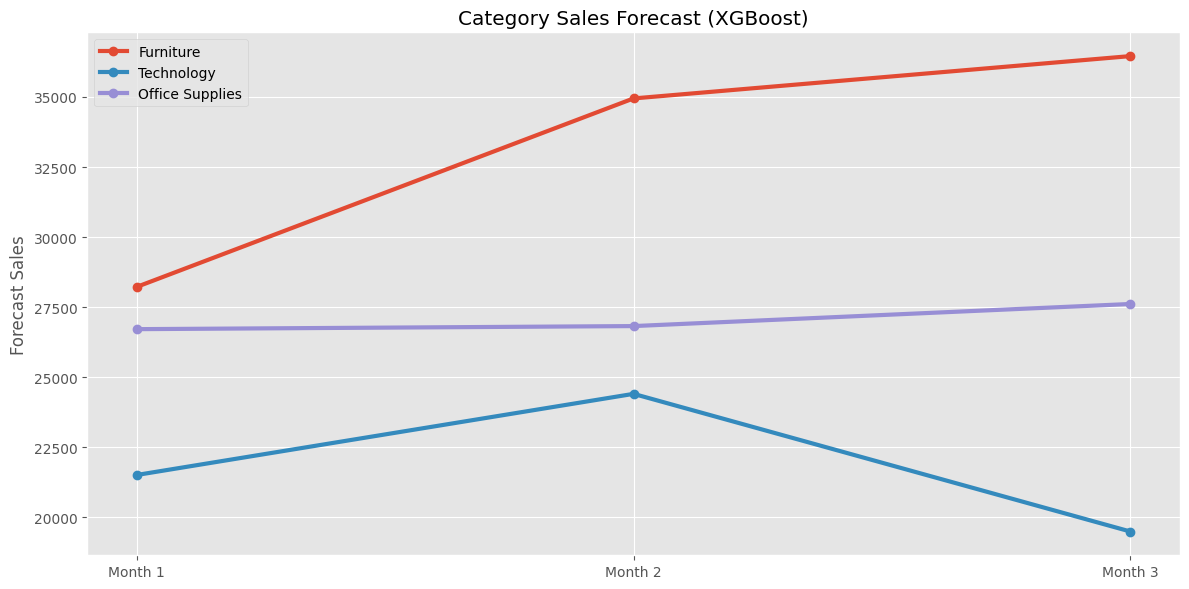

In [178]:
plt.figure(figsize=(12,6))

plt.plot(
    category_forecast["Month"],
    category_forecast["Furniture"],
    marker='o',
    linewidth=3,
    label="Furniture"
)

plt.plot(
    category_forecast["Month"],
    category_forecast["Technology"],
    marker='o',
    linewidth=3,
    label="Technology"
)

plt.plot(
    category_forecast["Month"],
    category_forecast["Office Supplies"],
    marker='o',
    linewidth=3,
    label="Office Supplies"
)

plt.title("Category Sales Forecast (XGBoost)")

plt.ylabel("Forecast Sales")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
   r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/category_forecast.png",
    dpi=300
)

plt.show()

In [ ]:
category_forecast.to_csv(
    "category_forecast.csv",
    index=False
)

## Product Category Interpretation

The XGBoost model forecasts sales separately for each product category.

Comparing the three forecast curves helps identify which product category is expected to experience stronger demand over the next three months.

These forecasts can support inventory planning, marketing campaigns, and category-level budgeting.

In [180]:
west_data, west_pred = xgb_forecast(
    sales,
    "Region",
    "West"
)

print(west_pred)

[20917.566 21304.805 27241.03 ]


In [181]:
east_data, east_pred = xgb_forecast(
    sales,
    "Region",
    "East"
)

print(east_pred)

[27948.287 28710.186 25092.363]


In [182]:
region_forecast = pd.DataFrame({

    "Month":[ "Month 1", "Month 2", "Month 3" ],"West":west_pred,"East":east_pred})
region_forecast

,Month,West,East
0,Month 1,20917.566406,27948.287109
1,Month 2,21304.804688,28710.185547
2,Month 3,27241.029297,25092.363281


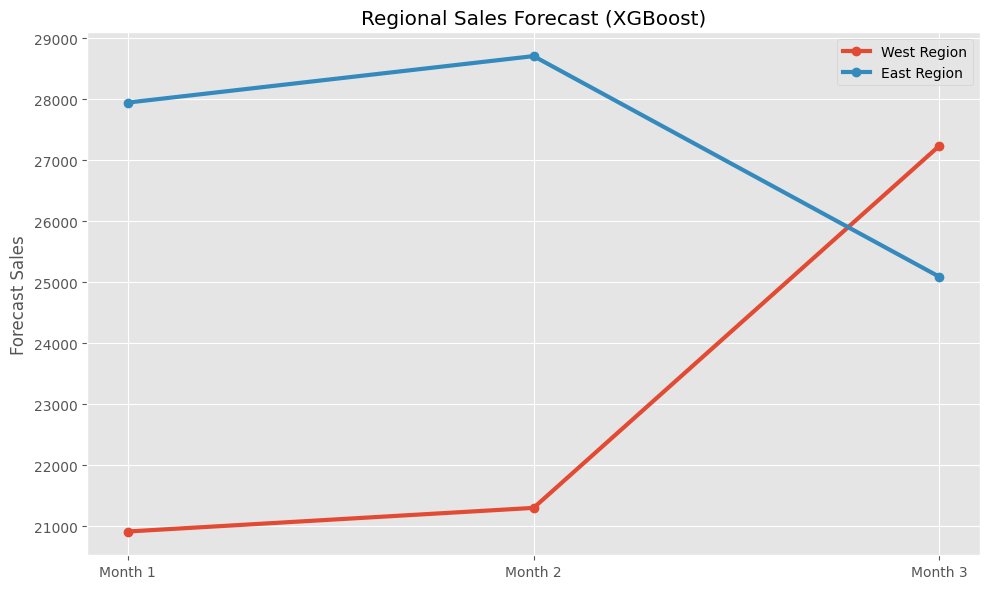

In [183]:
plt.figure(figsize=(10,6))

plt.plot(
    region_forecast["Month"],
    region_forecast["West"],
    marker='o',
    linewidth=3,
    label="West Region"
)

plt.plot(
    region_forecast["Month"],
    region_forecast["East"],
    marker='o',
    linewidth=3,
    label="East Region"
)

plt.title("Regional Sales Forecast (XGBoost)")

plt.ylabel("Forecast Sales")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/region_forecast.png",
    dpi=300
)

plt.show()

In [184]:
region_forecast.to_csv(
    "region_forecast.csv",
    index=False
)

In [185]:
forecast_comparison = pd.DataFrame({

    "Month":[
        "Month 1",
        "Month 2",
        "Month 3"
    ],

    "Furniture":furniture_pred,

    "Technology":technology_pred,

    "Office Supplies":office_pred,

    "West Region":west_pred,

    "East Region":east_pred

})

forecast_comparison

,Month,Furniture,Technology,Office Supplies,West Region,East Region
0,Month 1,28224.320312,21514.380859,26716.542969,20917.566406,27948.287109
1,Month 2,34947.246094,24408.128906,26826.187500,21304.804688,28710.185547
2,Month 3,36457.644531,19497.705078,27614.333984,27241.029297,25092.363281


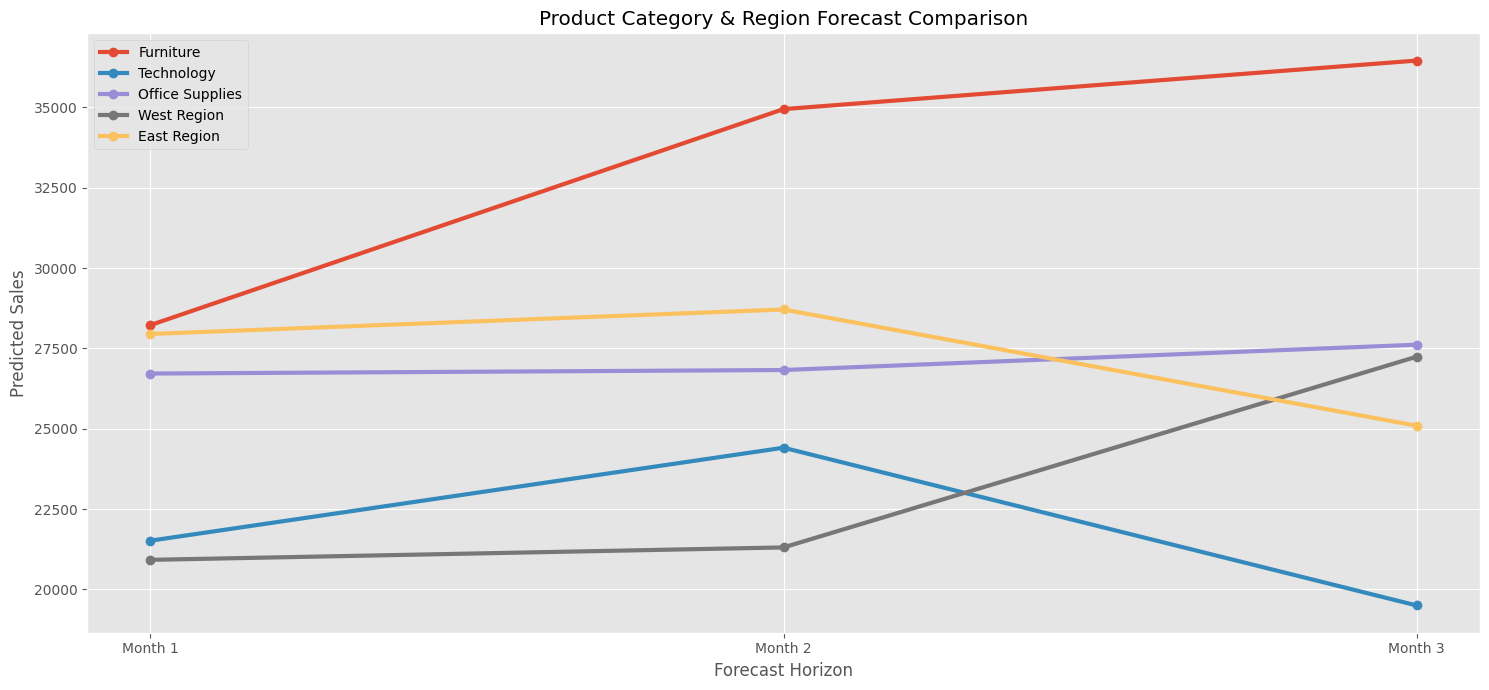

In [186]:
plt.figure(figsize=(15,7))

plt.plot(
    forecast_comparison["Month"],
    forecast_comparison["Furniture"],
    marker='o',
    linewidth=3,
    label="Furniture"
)

plt.plot(
    forecast_comparison["Month"],
    forecast_comparison["Technology"],
    marker='o',
    linewidth=3,
    label="Technology"
)

plt.plot(
    forecast_comparison["Month"],
    forecast_comparison["Office Supplies"],
    marker='o',
    linewidth=3,
    label="Office Supplies"
)

plt.plot(
    forecast_comparison["Month"],
    forecast_comparison["West Region"],
    marker='o',
    linewidth=3,
    label="West Region"
)

plt.plot(
    forecast_comparison["Month"],
    forecast_comparison["East Region"],
    marker='o',
    linewidth=3,
    label="East Region"
)

plt.title("Product Category & Region Forecast Comparison")

plt.xlabel("Forecast Horizon")

plt.ylabel("Predicted Sales")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/task4_comparison_forecast.png",
    dpi=300
)

plt.show()

In [187]:
growth = {

    "Furniture": furniture_pred[-1] - furniture_pred[0],

    "Technology": technology_pred[-1] - technology_pred[0],

    "Office Supplies": office_pred[-1] - office_pred[0],

    "West Region": west_pred[-1] - west_pred[0],

    "East Region": east_pred[-1] - east_pred[0]

}

growth_table = pd.DataFrame(

    growth.items(),

    columns=["Segment","Growth"]

)

growth_table = growth_table.sort_values(

    by="Growth",

    ascending=False

)

growth_table

,Segment,Growth
0,Furniture,8233.324219
3,West Region,6323.462891
2,Office Supplies,897.791016
1,Technology,-2016.675781
4,East Region,-2855.923828


In [189]:
best_segment = growth_table.iloc[0]
print("Strongest Upcoming Growth")
print(best_segment)

Strongest Upcoming Growth
Segment      Furniture
Growth     8233.324219
Name: 0, dtype: object


In [190]:
growth_table.to_csv(
    "growth_comparison.csv",
    index=False
)

# Business Interpretation

The XGBoost model was selected because it achieved the lowest forecasting error in Task 3.

Forecasts were generated separately for three product categories and two major sales regions.

The comparison chart highlights expected sales trends across all five segments.

The growth comparison table indicates which segment is expected to experience the strongest increase in sales over the next three months.

These insights can help management prioritize inventory allocation, marketing campaigns, staffing decisions, and regional sales strategies.

In [192]:
print("Segment with Highest Growth")
print(growth_table.iloc[0]["Segment"])
print()
print("Expected Growth")
print(round(growth_table.iloc[0]["Growth"],2))

Segment with Highest Growth
Furniture

Expected Growth
8233.32


In [193]:
weekly_sales = sales.groupby(pd.Grouper(key='Order Date',freq='W'))['Sales'].sum().reset_index()
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


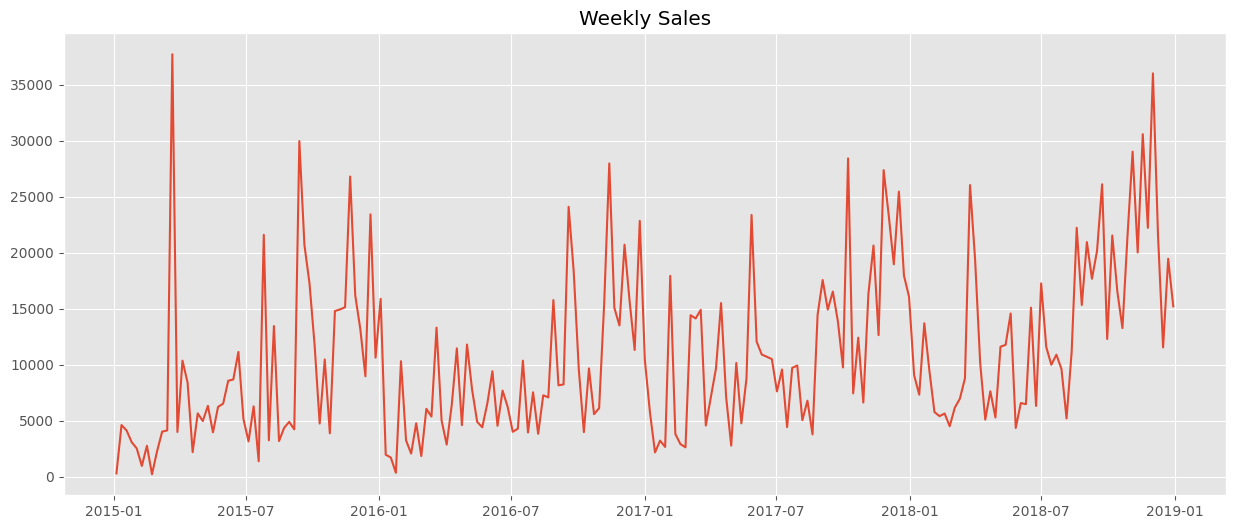

In [194]:
plt.figure(figsize=(15,6))
plt.plot(weekly_sales["Order Date"],weekly_sales["Sales"])
plt.title("Weekly Sales")
plt.grid(True)
plt.show()

In [196]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest( contamination=0.05, random_state=42)
weekly_sales["Isolation"] = iso.fit_predict(weekly_sales[["Sales"]])

In [197]:
iso_anomalies = weekly_sales[
weekly_sales["Isolation"] == -1]
print("Isolation Forest Anomalies")
print(len(iso_anomalies))
iso_anomalies.head()

Isolation Forest Anomalies
11


,Order Date,Sales,Isolation
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1


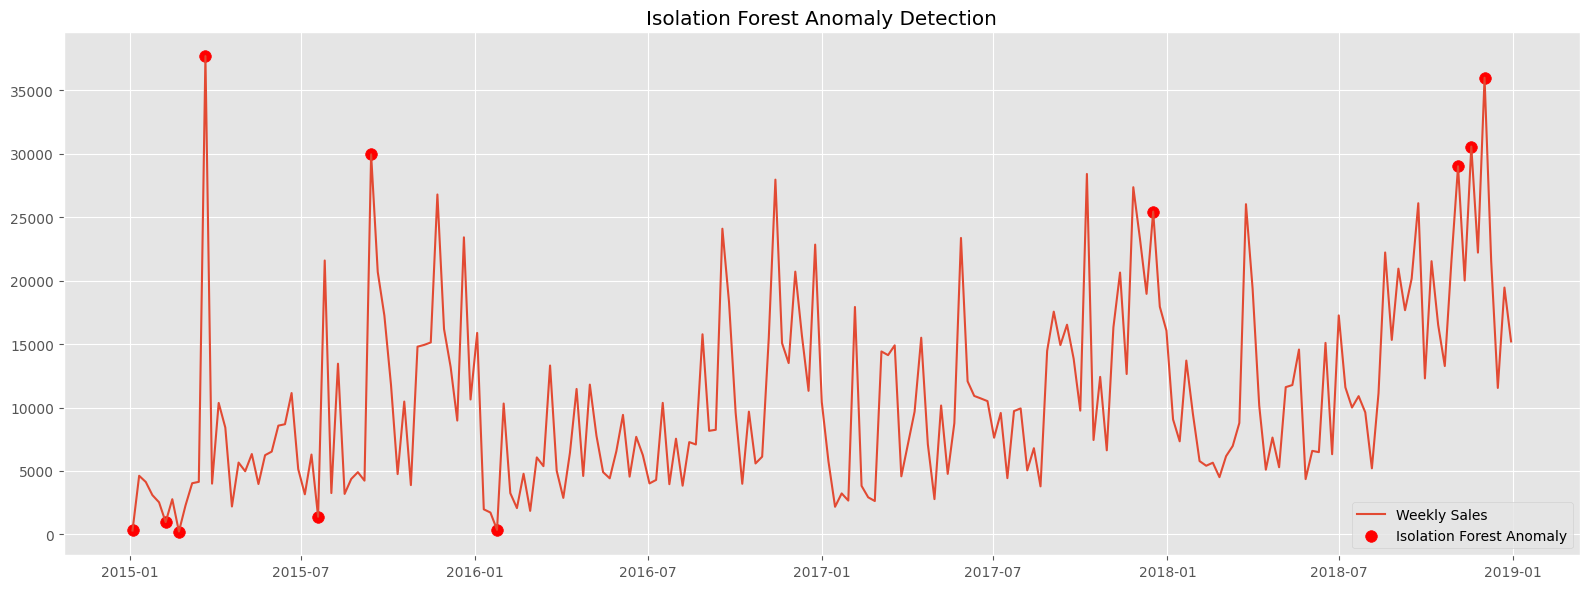

In [198]:
plt.figure(figsize=(16,6))
plt.plot(weekly_sales["Order Date"],weekly_sales["Sales"],label="Weekly Sales")
plt.scatter(iso_anomalies["Order Date"],iso_anomalies["Sales"],color="red",s=70,label="Isolation Forest Anomaly")
plt.title("Isolation Forest Anomaly Detection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/isolation_forest_anomalies.png",dpi=300)
plt.show()

## Isolation Forest

Isolation Forest isolates observations by randomly partitioning the data.

Observations that require fewer splits to isolate are considered anomalies.

This approach is particularly useful for detecting unusual spikes or drops in sales without assuming a normal distribution.

In [199]:
weekly_sales["RollingMean"] = weekly_sales["Sales"].rolling(4).mean()
weekly_sales["RollingStd"] = weekly_sales["Sales"].rolling(4).std()

In [200]:
weekly_sales["ZScore"] = ( weekly_sales["Sales"] -weekly_sales["RollingMean"])/weekly_sales["RollingStd"]

In [203]:
z_anomalies = weekly_sales[

    abs(weekly_sales["ZScore"])>2]

print("Rolling Z-Score Anomalies")
print(len(z_anomalies))
z_anomalies.head()

Rolling Z-Score Anomalies
0


,Order Date,Sales,Isolation,RollingMean,RollingStd,ZScore


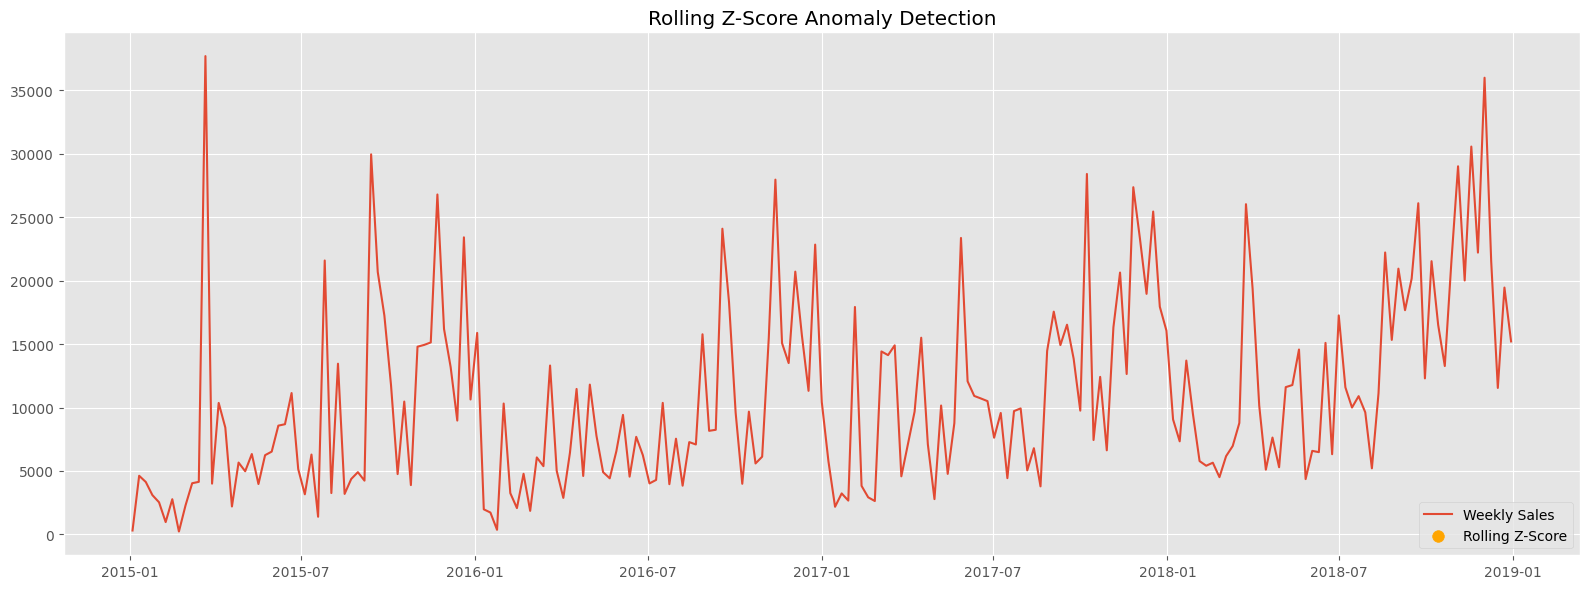

In [204]:
plt.figure(figsize=(16,6))

plt.plot(weekly_sales["Order Date"],weekly_sales["Sales"],label="Weekly Sales")
plt.scatter(z_anomalies["Order Date"],z_anomalies["Sales"],color="orange",s=70,label="Rolling Z-Score")
plt.title("Rolling Z-Score Anomaly Detection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/zscore_anomalies.png",dpi=300)
plt.show()

In [205]:
comparison = weekly_sales.copy()
comparison["Isolation"] = comparison["Isolation"]==-1
comparison["Rolling_Z"] = abs(comparison["ZScore"]
)>2

comparison[
    [
        "Order Date",
        "Sales",
        "Isolation",
        "Rolling_Z"
    ]
].head(20)

,Order Date,Sales,Isolation,Rolling_Z
0,2015-01-04,304.508,True,False
1,2015-01-11,4619.108,False,False
2,2015-01-18,4130.533,False,False
3,2015-01-25,3092.544,False,False
4,2015-02-01,2527.914,False,False
5,2015-02-08,968.534,True,False
6,2015-02-15,2771.054,False,False
7,2015-02-22,224.912,True,False
8,2015-03-01,2289.643,False,False
9,2015-03-08,4030.728,False,False


In [206]:
common = comparison[
(comparison["Isolation"])  &(comparison["Rolling_Z"])]
print("Common anomalies")
print(len(common))
common

Common anomalies
0


,Order Date,Sales,Isolation,RollingMean,RollingStd,ZScore,Rolling_Z


In [207]:
comparison.to_csv(

    "weekly_anomaly_detection.csv",

    index=False

)

In [208]:
explanation = comparison[
    (comparison["Isolation"]) |
    (comparison["Rolling_Z"])
][[
    "Order Date",
    "Sales",
    "Isolation",
    "Rolling_Z"
]].copy()

explanation["Possible Business Reason"] = (
    "Possible festive season sale, promotional campaign, bulk corporate order, "
    "inventory clearance event, or unusually low sales due to supply disruptions."
)

explanation

,Order Date,Sales,Isolation,Rolling_Z,Possible Business Reason
0,2015-01-04,304.508,True,False,"Possible festive season sale, promotional camp..."
5,2015-02-08,968.534,True,False,"Possible festive season sale, promotional camp..."
7,2015-02-22,224.912,True,False,"Possible festive season sale, promotional camp..."
11,2015-03-22,37703.665,True,False,"Possible festive season sale, promotional camp..."
28,2015-07-19,1387.686,True,False,"Possible festive season sale, promotional camp..."
36,2015-09-13,29959.137,True,False,"Possible festive season sale, promotional camp..."
55,2016-01-24,358.522,True,False,"Possible festive season sale, promotional camp..."
154,2017-12-17,25449.800,True,False,"Possible festive season sale, promotional camp..."
200,2018-11-04,29017.467,True,False,"Possible festive season sale, promotional camp..."
202,2018-11-18,30572.447,True,False,"Possible festive season sale, promotional camp..."


# Comparison of Both Methods

## Isolation Forest

Isolation Forest detects anomalies using machine learning by isolating observations that differ significantly from the rest of the dataset.

## Rolling Z-Score

The Rolling Z-Score method identifies anomalies by measuring how far weekly sales deviate from the local rolling average.

## Comparison

- Some weeks are detected by both methods, indicating strong evidence of unusual sales behaviour.
- Isolation Forest may identify additional anomalies because it does not assume a normal distribution.
- Rolling Z-Score is more conservative and focuses on deviations relative to recent weeks.

The combination of both methods provides a more robust anomaly detection strategy.

In [209]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import numpy as np

In [210]:
monthly = sales.groupby(
    [pd.Grouper(key='Order Date', freq='ME'),'Sub-Category'])['Sales'].sum().reset_index()
monthly.head()

,Order Date,Sub-Category,Sales
0,2015-01-31,Accessories,827.890
1,2015-01-31,Appliances,312.580
2,2015-01-31,Art,176.990
3,2015-01-31,Binders,814.508
4,2015-01-31,Bookcases,1010.055


In [211]:
total_sales = monthly.groupby('Sub-Category')['Sales'].sum()

In [212]:
volatility = monthly.groupby(
    'Sub-Category'
)['Sales'].std()

In [213]:
avg_order = sales.groupby('Sub-Category')['Sales'].mean()

In [214]:
yearly = sales.groupby(
    [sales['Order Date'].dt.year,'Sub-Category'])['Sales'].sum().reset_index()
pivot = yearly.pivot(
    index='Sub-Category',
    columns='Order Date',
    values='Sales')
growth = (
    pivot.iloc[:, -1] - pivot.iloc[:, 0]) / pivot.iloc[:, 0] * 100
growth = growth.fillna(0)

In [215]:
cluster_data = pd.DataFrame({"Total Sales": total_sales,
"Growth Rate": growth,"Volatility": volatility,"Average Order Value": avg_order})
cluster_data = cluster_data.fillna(0)
cluster_data

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224
Chairs,322822.7310,20.954677,4407.232960,531.833165
Copiers,146248.0940,479.729510,5500.774391,2215.880212
Envelopes,16128.0460,-12.121345,228.218688,65.032444
Fasteners,3001.9600,30.468364,48.742229,14.027850


## Feature Engineering

Each product sub-category is represented by:

- Total Sales
- Growth Rate (%)
- Monthly Sales Volatility
- Average Order Value

These features describe both sales performance and demand behaviour.

In [217]:
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_data)

In [218]:
wcss = []
for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10)

    model.fit(scaled)

    wcss.append(model.inertia_)

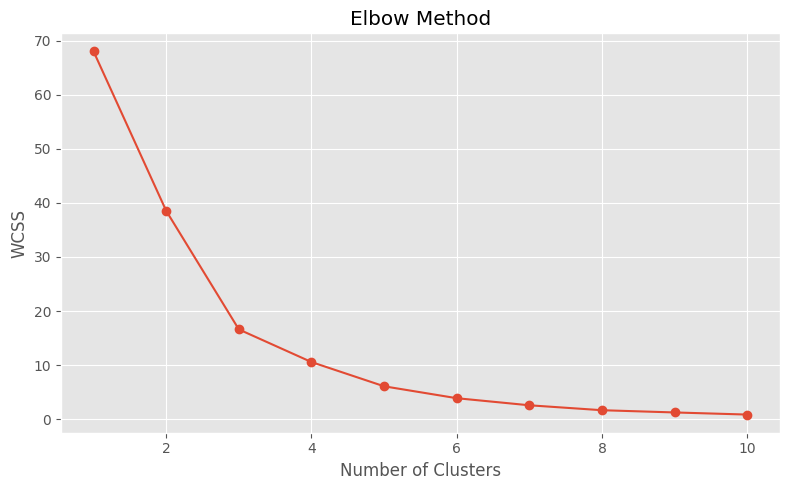

In [219]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/elbow_method.png",dpi=300)
plt.show()

In [220]:
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
cluster_data["Cluster"] = kmeans.fit_predict(scaled)
cluster_data.head()

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,0
Appliances,104618.4030,165.242912,1821.621539,227.926804,2
Art,26705.4100,49.649531,330.488343,34.019631,2
Binders,200028.7850,65.778638,3848.223648,134.067550,0
Bookcases,113813.1987,49.846598,2220.405080,503.598224,2


In [221]:
pca = PCA(n_components=2)
components = pca.fit_transform(scaled)
cluster_data["PCA1"] = components[:,0]
cluster_data["PCA2"] = components[:,1]

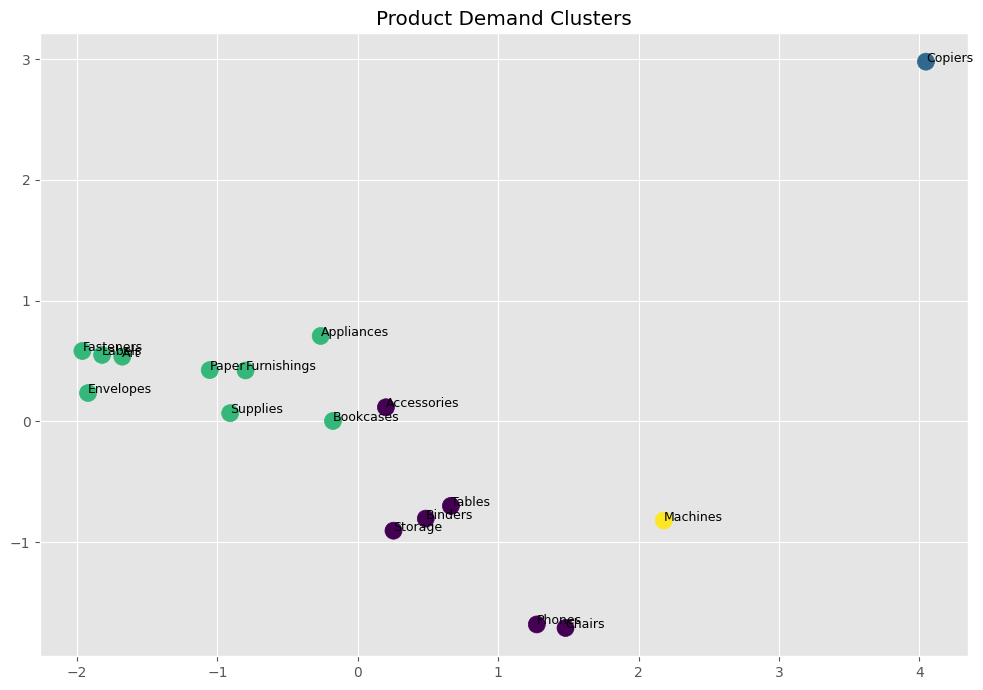

In [222]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(cluster_data["PCA1"],cluster_data["PCA2"],c=cluster_data["Cluster"],s=150)

for i in cluster_data.index:

    plt.text(cluster_data.loc[i,"PCA1"],cluster_data.loc[i,"PCA2"],i,fontsize=9)

plt.title("Product Demand Clusters")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    r"C:\Users\saash\OneDrive\Desktop\SalesForecasting_Aashi\Charts/product_clusters.png",dpi=300)
plt.show()

In [223]:
cluster_summary = cluster_data.groupby(
    "Cluster"
).mean(numeric_only=True)

cluster_summary

,Total Sales,Growth Rate,Volatility,Average Order Value,PCA1,PCA2
Cluster,,,,,,
0,239495.780667,56.465168,3489.056075,361.131228,0.726087,-0.948011
1,146248.094000,479.729510,5500.774391,2215.880212,4.046026,2.979941
2,54341.708189,58.795823,1031.431565,142.746758,-1.175792,0.392146
3,189238.631000,-29.793120,5603.554747,1645.553313,2.179582,-0.821189


In [224]:
cluster_labels = {

    0:"High Volume, Stable Demand",
    1:"Growing Demand",
    2:"Low Volume, High Volatility",
    3:"Declining Demand"}

cluster_data["Demand Segment"] = cluster_data[
    "Cluster"
].map(cluster_labels)

cluster_data

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PCA1,PCA2,Demand Segment
Sub-Category,,,,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,0,0.200367,0.116729,"High Volume, Stable Demand"
Appliances,104618.4030,165.242912,1821.621539,227.926804,2,-0.264248,0.707660,"Low Volume, High Volatility"
Art,26705.4100,49.649531,330.488343,34.019631,2,-1.676784,0.535820,"Low Volume, High Volatility"
Binders,200028.7850,65.778638,3848.223648,134.067550,0,0.484161,-0.805597,"High Volume, Stable Demand"
Bookcases,113813.1987,49.846598,2220.405080,503.598224,2,-0.176589,0.003166,"Low Volume, High Volatility"
Chairs,322822.7310,20.954677,4407.232960,531.833165,0,1.479554,-1.711393,"High Volume, Stable Demand"
Copiers,146248.0940,479.729510,5500.774391,2215.880212,1,4.046026,2.979941,Growing Demand
Envelopes,16128.0460,-12.121345,228.218688,65.032444,2,-1.920711,0.234844,"Low Volume, High Volatility"
Fasteners,3001.9600,30.468364,48.742229,14.027850,2,-1.960973,0.583155,"Low Volume, High Volatility"


In [225]:
cluster_data.to_csv(
    "product_clusters.csv",
    index=True
)

# Business Interpretation

The K-Means algorithm grouped product sub-categories into four demand segments.

These clusters represent different demand characteristics based on sales performance, growth, volatility, and average order value.

The segmentation enables businesses to prioritize inventory, optimize replenishment, and improve product planning.

# Recommended Stocking Strategy

## High Volume, Stable Demand

- Maintain high inventory levels.
- Ensure continuous replenishment.
- Monitor stock-outs closely.

## Growing Demand

- Increase inventory gradually.
- Allocate additional marketing resources.
- Monitor demand trends monthly.

## Low Volume, High Volatility

- Maintain limited inventory.
- Use demand-driven replenishment.
- Avoid overstocking.

## Declining Demand

- Reduce inventory levels.
- Clear excess stock through promotions.
- Review product portfolio regularly.